# Projet Final Machine Learning: Covertype

### Execitive Master IA et Science des données

# Introduction

La prédiction du type de couverture forestière à partir de variables cartographiques est un problème classique d'apprentissage supervisé. À partir de caractéristiques de terrain (altitude, pente, orientation, distances à l'eau, aux routes et aux points de feu, indices d'ensoleillement, zone géographique et type de sol), l'objectif est de prédire automatiquement, parmi sept types de forêt, celui qui recouvre une parcelle de 30 × 30 mètres.

Ce projet vise à **construire et comparer plusieurs modèles de classification** sur un jeu de données volumineux et déséquilibré, afin d'identifier l'approche la plus performante et de comprendre *pourquoi* elle l'est. Il met l'accent sur quatre enjeux : la **gestion d'un grand volume de données** (échantillonnage, temps de calcul, passage à l'échelle), l'étude des **méthodes à base d'arbres** (arbre seul, forêt aléatoire, boosting), le **traitement du déséquilibre des classes** (pondération, sur-échantillonnage, seuils de décision), et l'**interprétabilité** (importance des variables, apport du feature engineering).

## Descriptif des données

Le jeu de données **Forest Covertype** (UCI, accessible via `sklearn.datasets.fetch_covtype`) comporte **581 012 observations** et **54 variables explicatives**, pour une cible à **7 classes**.

Les variables se répartissent en trois groupes :
- **10 variables quantitatives** : altitude (`Elevation`), orientation (`Aspect`), pente (`Slope`), distances horizontale et verticale à l'hydrologie, distance aux routes, distance aux points de feu, et trois indices d'ensoleillement (`Hillshade` à 9h, midi, 15h) ;
- **4 indicatrices de zone sauvage** (`Wilderness_Area`, encodage one-hot) ;
- **40 indicatrices de type de sol** (`Soil_Type`, encodage one-hot).

La cible `Cover_Type` distingue sept essences : Spruce/Fir (1), Lodgepole Pine (2), Ponderosa Pine (3), Cottonwood/Willow (4), Aspen (5), Douglas-fir (6) et Krummholz (7).

**Caractéristiques notables** identifiées lors de l'exploration :
- **Fort déséquilibre des classes** : les types 1 et 2 représentent à eux seuls ~85 % des observations, tandis que le type 4 ne compte que ~0,5 % des données. Ce déséquilibre justifie l'usage de la stratification et du **macro-F1** comme métrique de référence.
- **Aucune valeur manquante**, données entièrement numériques.
- **L'altitude est de loin la variable la plus discriminante** (score F ANOVA largement supérieur aux autres) : les types de forêt s'organisent en bandes d'altitude nettes.
- Certaines variables sont **redondantes** (les deux distances à l'eau, les indices d'ensoleillement liés à l'orientation) ou **peu informatives sous forme brute** (`Aspect`, variable circulaire). Ces constats ont directement guidé le feature engineering.

Un **feature engineering spécifique au covtype** a été appliqué : encodage circulaire de l'orientation (`Aspect` → `sin`/`cos`), altitude corrigée par la distance à l'eau (`EVDtH`, `EHDtH` — qui se révéleront parmi les variables les plus décisives), distance euclidienne à l'hydrologie, sommes et écarts de distances (hydrologie / routes / feux), et résumé d'ensoleillement (`Hillshade_mean`). Les deux distances brutes à l'hydrologie, devenues redondantes une fois leur information extraite, ont été retirées. Le jeu passe ainsi de 54 à 63 variables.

## Plan de l'étude

1. **Analyse exploratoire (EDA)** : distributions par classe, corrélations, pouvoir discriminant des variables, séparabilité visuelle (projections, nuages colorés).
2. **Feature engineering** spécifique au covtype et préparation : sous-échantillon stratifié de 80 000 lignes (pour maîtriser le temps de calcul), découpage train/validation, standardisation sans fuite de données (réservée aux modèles qui en ont besoin).
3. **Modélisation** : entraînement et optimisation par validation croisée (sélection en **macro-F1**) de sept modèles — régression logistique, arbre de décision, forêt aléatoire, k plus proches voisins, SVM à noyau, XGBoost et LightGBM. Pour chacun, des **courbes biais-variance** et des **courbes ROC** éclairent le comportement du modèle.
4. **Comparaison** : tableau récapitulatif des performances (accuracy, macro-F1, weighted-F1) et réduction de dimension par **PCA**.
5. **Traitement du déséquilibre** : comparaison baseline / pondération des classes / SMOTENC, puis ajustement des **seuils de décision par classe**.
6. **Combinaison de modèles** : **stacking** RF + XGBoost + LightGBM.
7. **Évaluation finale et passage à l'échelle** : test sur un jeu indépendant (~500 000 lignes jamais vues), puis entraînement sur l'**intégralité des 581 012 observations**, avec matrice de confusion et analyse par classe.
8. **Interprétabilité** : importance des variables (gain interne et permutation) et **courbe d'apprentissage** quantifiant l'effet de la quantité de données sur les classes rares.

# 1. Imports et chargement

In [6]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, StackingClassifier,
                              HistGradientBoostingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTENC

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', 500)
RANDOM_STATE = 42

cov = fetch_covtype(as_frame=True)
X = cov.data            # (581012, 54)
y = cov.target          # classes 1..7
print("Donnees completes :", X.shape)

Donnees completes : (581012, 54)


In [2]:
df = pd.concat([X, y], axis=1)
display(df.head())

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_0,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Soil_Type_0,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


# 2. Découverte descriptive

In [3]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           581012 non-null  float64
 1   Aspect                              581012 non-null  float64
 2   Slope                               581012 non-null  float64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  float64
 4   Vertical_Distance_To_Hydrology      581012 non-null  float64
 5   Horizontal_Distance_To_Roadways     581012 non-null  float64
 6   Hillshade_9am                       581012 non-null  float64
 7   Hillshade_Noon                      581012 non-null  float64
 8   Hillshade_3pm                       581012 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  float64
 10  Wilderness_Area_0                   581012 non-null  float64
 11  Wilderness_Area_1         

In [4]:
wild  = [c for c in X.columns if c.startswith("Wilderness_Area")]
soil  = [c for c in X.columns if c.startswith("Soil_Type")]
quant = [c for c in X.columns if c not in wild + soil]
print(f"{len(quant)} quantitatives, {len(wild)} wilderness, {len(soil)} sols")
print("Valeurs manquantes :", df.isna().sum().sum())
print("\nRépartition des classes :")
print(y.value_counts(normalize=True).sort_index().round(3))

10 quantitatives, 4 wilderness, 40 sols
Valeurs manquantes : 0

Répartition des classes :
Cover_Type
1    0.365
2    0.488
3    0.062
4    0.005
5    0.016
6    0.030
7    0.035
Name: proportion, dtype: float64


In [5]:
categorical_variables = ["Cover_Type", "Wilderness_Area_0", "Wilderness_Area_1", "Wilderness_Area_2", "Wilderness_Area_3", "Soil_Type_0", "Soil_Type_1", "Soil_Type_2", "Soil_Type_3", "Soil_Type_4", "Soil_Type_5", "Soil_Type_6", "Soil_Type_7", "Soil_Type_8", "Soil_Type_9", "Soil_Type_10", "Soil_Type_11", "Soil_Type_12", "Soil_Type_13", "Soil_Type_14", "Soil_Type_15", "Soil_Type_16", "Soil_Type_17", "Soil_Type_18", "Soil_Type_19", "Soil_Type_20", "Soil_Type_21", "Soil_Type_22", "Soil_Type_23", "Soil_Type_24", "Soil_Type_25", "Soil_Type_26", "Soil_Type_27", "Soil_Type_28", "Soil_Type_29", "Soil_Type_30",  "Soil_Type_31", "Soil_Type_32", "Soil_Type_33", "Soil_Type_34", "Soil_Type_35", "Soil_Type_36", "Soil_Type_37", "Soil_Type_38", "Soil_Type_39"]
continuous_variables = ["Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology", "Horizontal_Distance_To_Roadways", "Horizontal_Distance_To_Fire_Points", "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm"]
continuous_variables_labels = ["Elevation", "Aspect", "Slope", "Horizontal Dist. To Hydrology", "Vertical Dist. To Hydrology", "Horizontal Dist. To Roadways", "Horizontal Dist. To Fire Points", "Hillshade 9am", "Hillshade Noon", "Hillshade 3pm"]

print(f'There are {len(categorical_variables)} categorical variables.')
print(f'There are {len(continuous_variables)} continuous variables.')

There are 45 categorical variables.
There are 10 continuous variables.


# 3. Exploratory Data Analysis
## 3.1 Cover types by wilderness area

In [6]:
cover_type_counts = df["Cover_Type"].value_counts().sort_index()
cover_type_counts

Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

In [7]:
wild = [c for c in df.columns if c.startswith("Wilderness_Area")]

# Label unique de zone (0..3) à partir du one-hot
wild_label = df[wild].values.argmax(axis=1)

# Tableau croisé Cover_Type × zone, ré-indexé pour garantir 7 lignes × 4 colonnes
ct = (pd.crosstab(df["Cover_Type"], wild_label)
        .reindex(index=range(1, 8), columns=range(len(wild)), fill_value=0))

area_0_counts = ct[0].to_numpy()
area_1_counts = ct[1].to_numpy()
area_2_counts = ct[2].to_numpy()
area_3_counts = ct[3].to_numpy()

<Axes: xlabel='Cover_Type'>

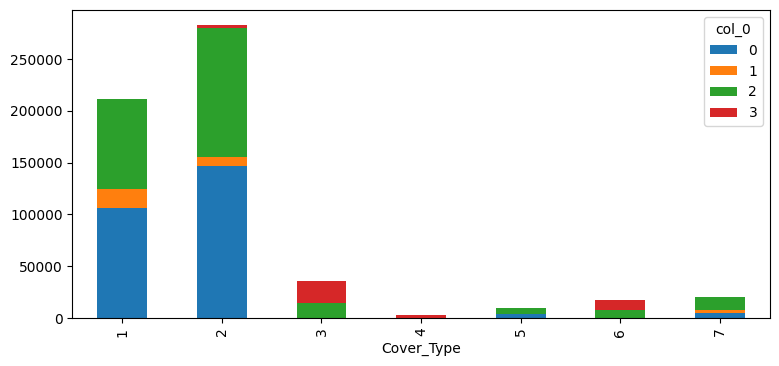

In [8]:
ct.plot.bar(stacked=True, figsize=(9, 4))

### Insights:

**Le déséquilibre est énorme.** Les types 1 et 2 dominent complètement (environ 210 000 et 280 000), alors que les types 4, 5 et 6 sont minuscules en comparaison. 

**Chaque forêt vit dans des zones précises** (les couleurs = les 4 zones wilderness). Les types 1 et 2 sont dans les zones 0 (bleu) et 2 (vert), les deux grandes zones. Les forêts plus rares (types 3, 4, 6) sont surtout dans la zone 3 (rouge). Le type 4, le plus rare, est presque uniquement dans la zone 3.

**Donc la zone est un bon indice.** Si l'on sait dans quelle zone on est, on réduis déjà beaucoup les forêts possibles : zone 3 → plutôt types 3, 4, 6 ; zones 0 et 2 → plutôt types 1, 2, 7. 

## 3.2 Distributions of continuous variables per cover type

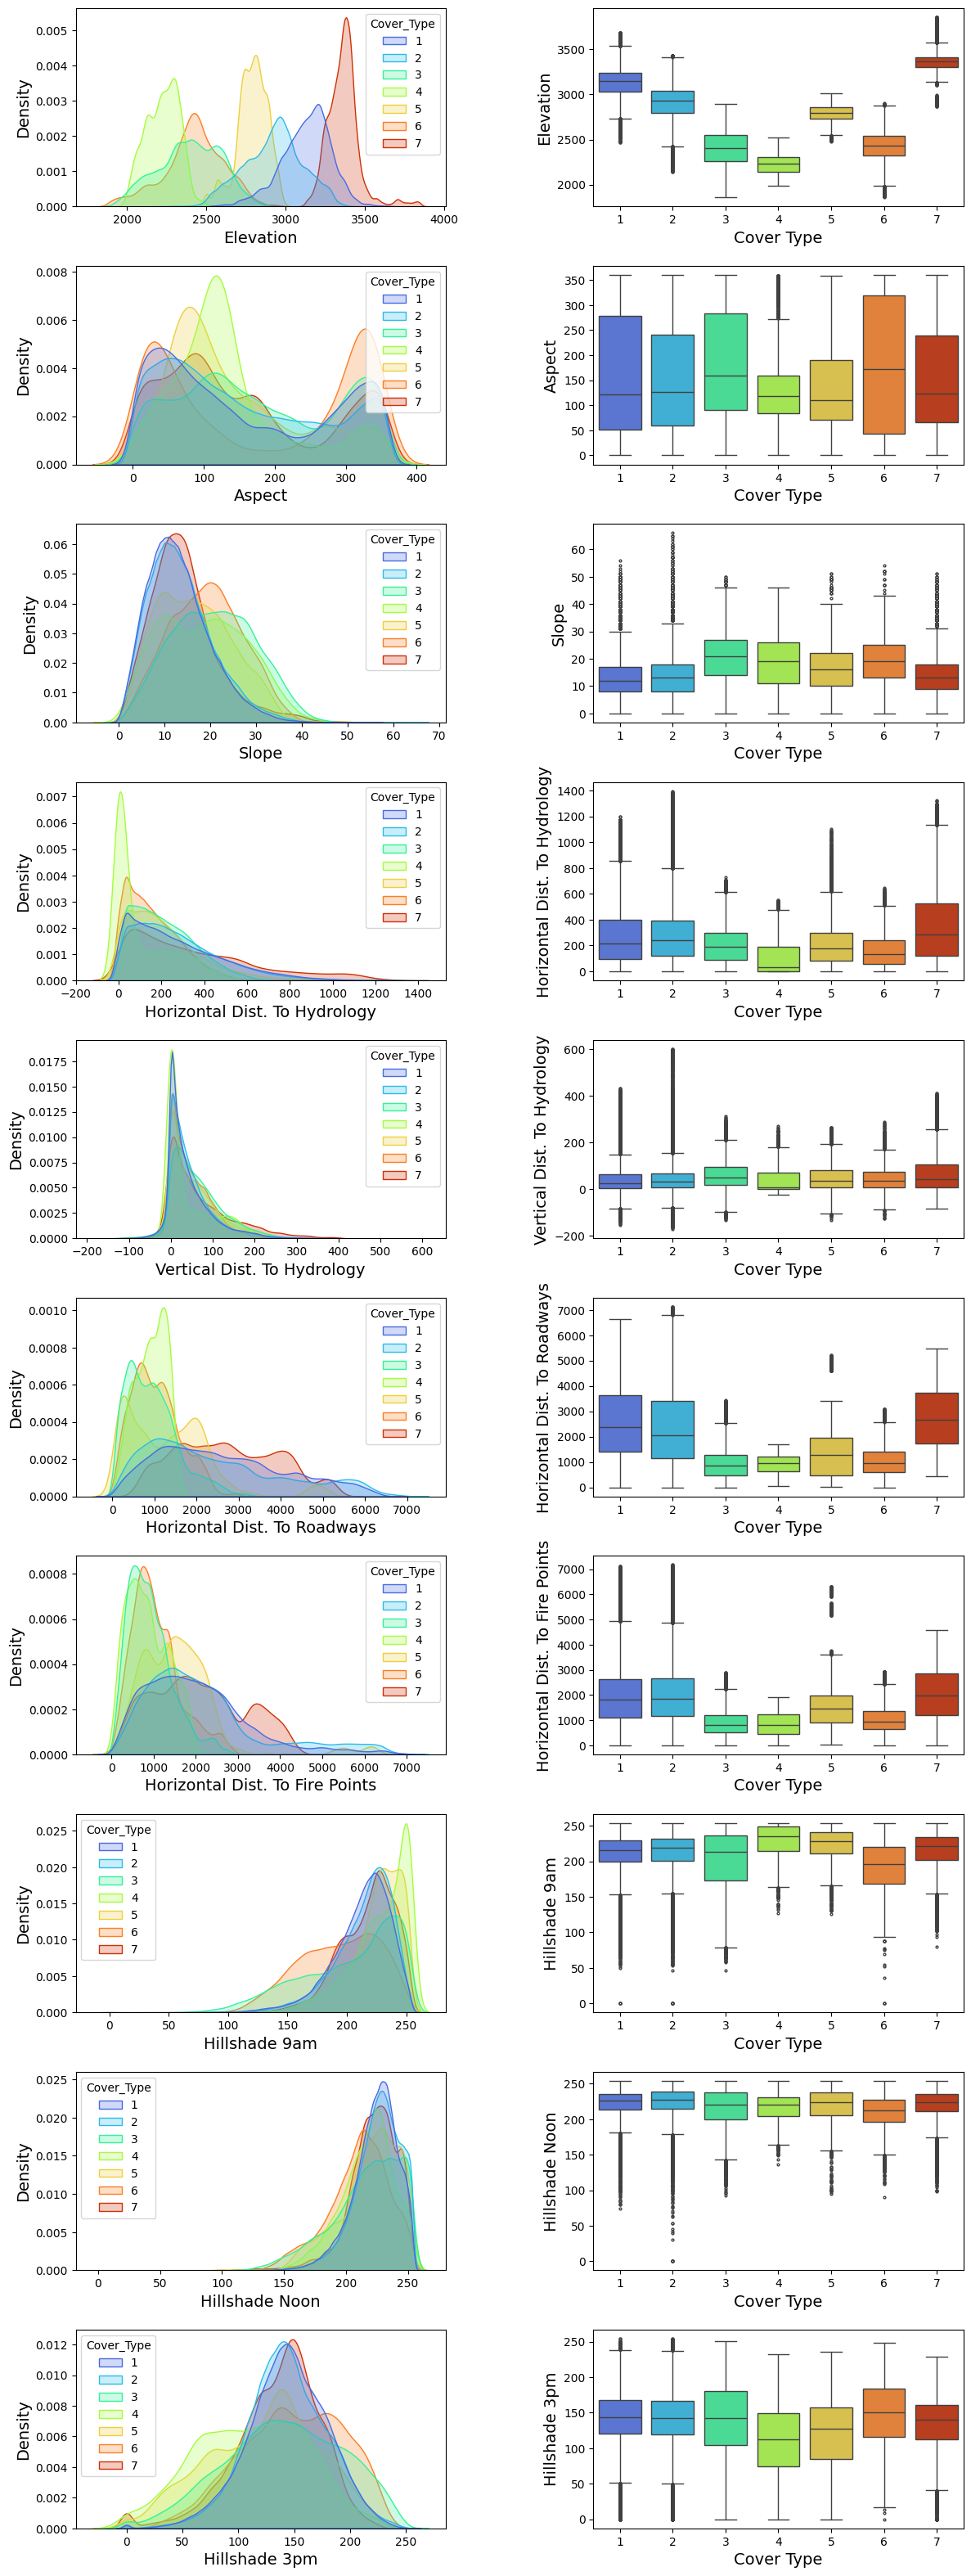

In [9]:
df_plot = df.copy()
df_plot["Cover_Type"] = df_plot["Cover_Type"].astype("category")

n = len(continuous_variables)
fig, axs = plt.subplots(n, 2, figsize=(14, 4 * n))

for i, (var, lab) in enumerate(zip(continuous_variables, continuous_variables_labels)):
    sns.kdeplot(data=df_plot, x=var, hue="Cover_Type", palette="turbo",
                fill=True, common_norm=False, ax=axs[i][0])
    sns.boxplot(data=df_plot, x="Cover_Type", y=var, hue="Cover_Type",
                palette="turbo", legend=False, fliersize=2, ax=axs[i][1])

    axs[i][0].set_xlabel(lab, fontsize=14)
    axs[i][0].set_ylabel("Density", fontsize=14)
    axs[i][1].set_xlabel("Cover Type", fontsize=14)
    axs[i][1].set_ylabel(lab, fontsize=14)

plt.subplots_adjust(wspace=0.4, hspace=0.3)
plt.show()

## 3.3 correlation map

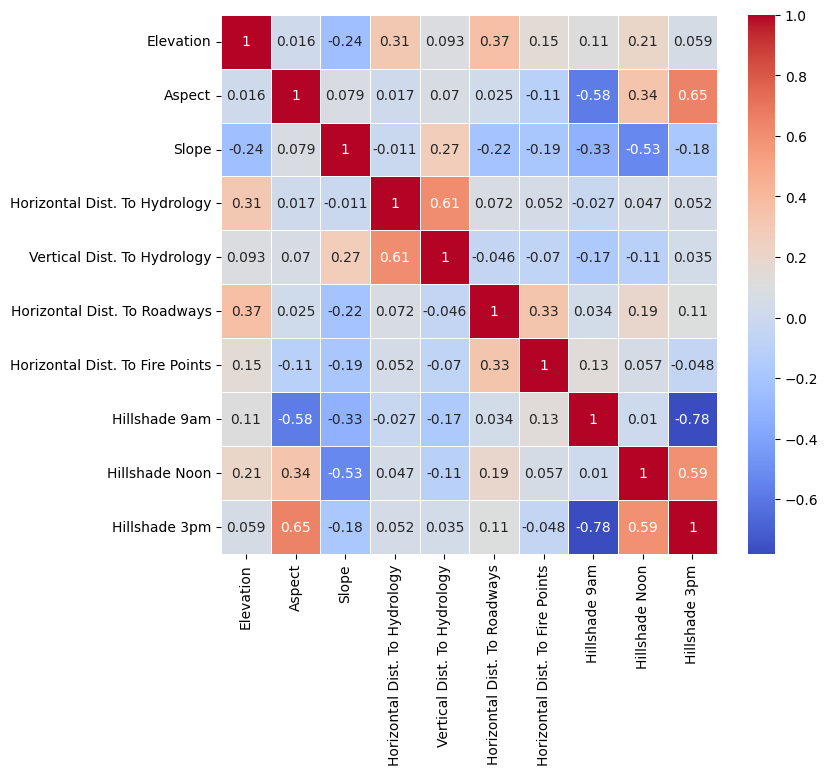

In [10]:
plt.figure(figsize=(8,7))
corr = df[continuous_variables].corr()
sns.heatmap(corr, xticklabels=continuous_variables_labels, yticklabels=continuous_variables_labels, linewidths=0.5, cmap='coolwarm', annot=True)
plt.show()

## 3.4 Jointplots of continuous variables:

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


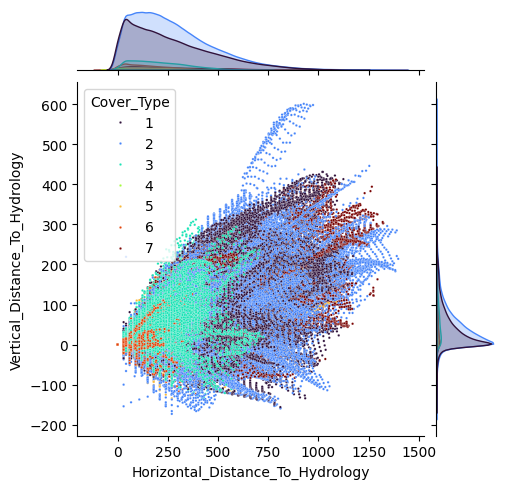

In [11]:
sns.jointplot(data=df, x="Horizontal_Distance_To_Hydrology", y="Vertical_Distance_To_Hydrology", hue="Cover_Type", palette='turbo', height=5, s=3)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


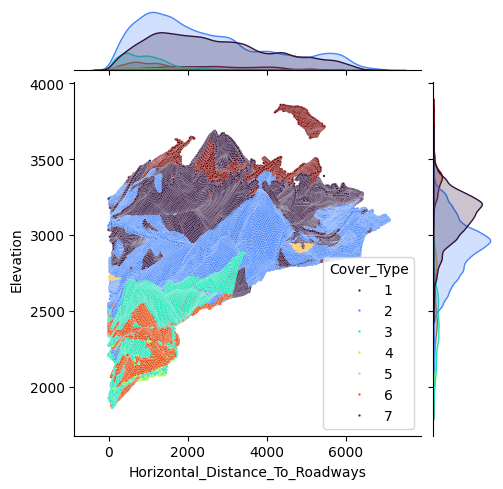

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


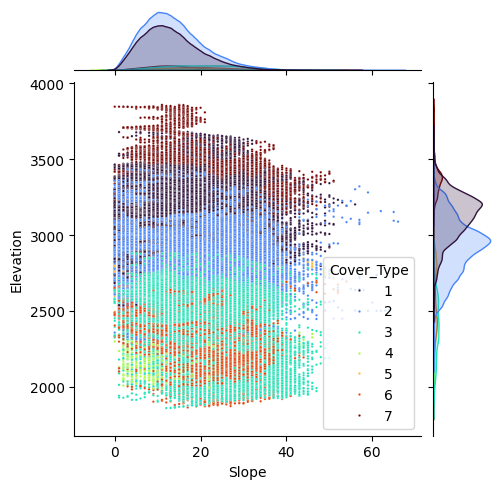

In [12]:
sns.jointplot(data=df, x="Horizontal_Distance_To_Roadways", y="Elevation", hue="Cover_Type", palette='turbo', height=5, s=3)
plt.show()

sns.jointplot(data=df, x="Slope", y="Elevation", hue="Cover_Type", palette='turbo', height=5, s=3)
plt.show()

## 3.5 Heatmap type de sol × type de forêt

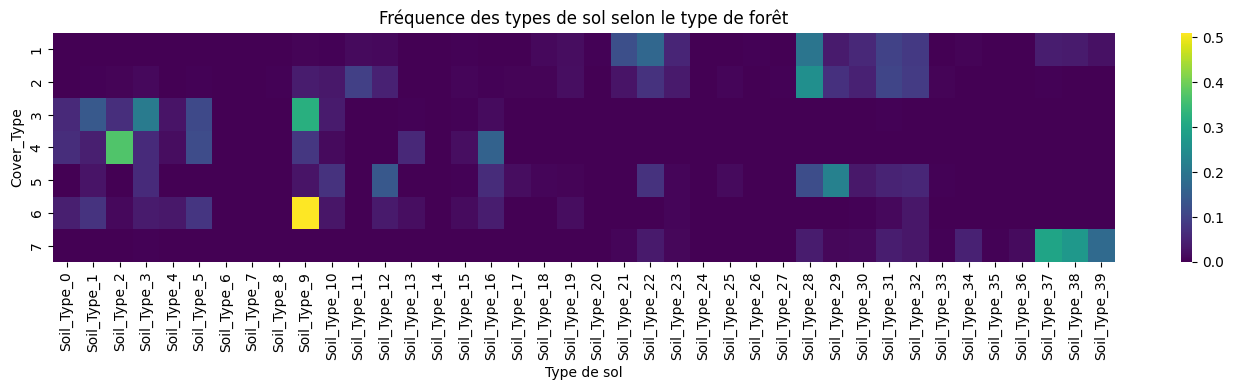

In [13]:
samp = X.sample(15000, random_state=42)
y_samp = y.loc[samp.index]

soil_by_cover = X[soil].groupby(y).mean()
plt.figure(figsize=(14, 4))
sns.heatmap(soil_by_cover, cmap='viridis')
plt.title('Fréquence des types de sol selon le type de forêt')
plt.xlabel('Type de sol'); plt.ylabel('Cover_Type')
plt.tight_layout(); plt.show()

## 3.6 Discriminant des variables (score F ANOVA)

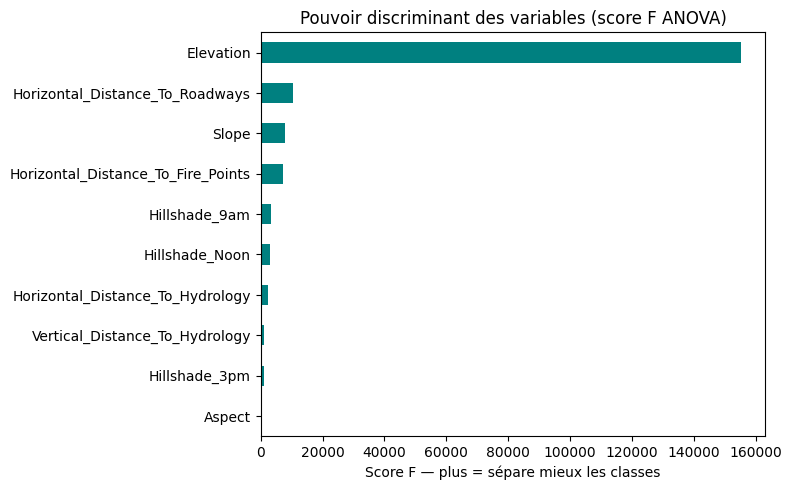

In [14]:
from sklearn.feature_selection import f_classif

F, _ = f_classif(X[quant], y)
fscore = pd.Series(F, index=quant).sort_values()

plt.figure(figsize=(8, 5))
fscore.plot.barh(color='teal')
plt.title('Pouvoir discriminant des variables (score F ANOVA)')
plt.xlabel('Score F — plus = sépare mieux les classes')
plt.tight_layout(); plt.show()

## 3.7 Nuage Elevation × Distance aux routes

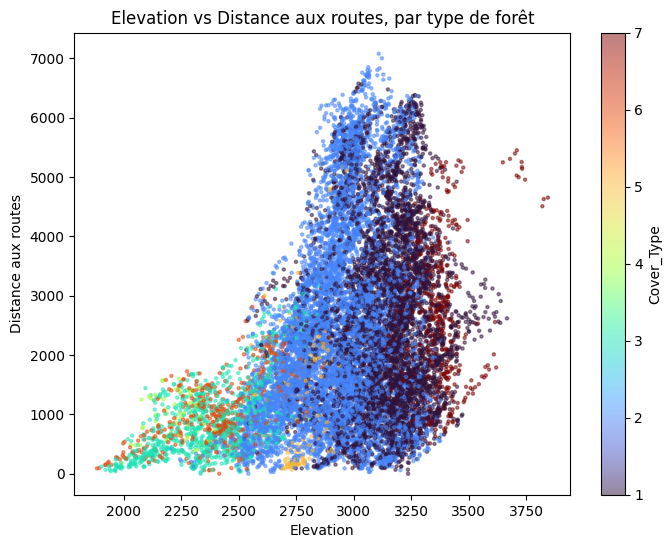

In [15]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(samp['Elevation'], samp['Horizontal_Distance_To_Roadways'],
                 c=y_samp, cmap='turbo', s=5, alpha=0.5)
plt.colorbar(sc, label='Cover_Type')
plt.xlabel('Elevation'); plt.ylabel('Distance aux routes')
plt.title('Elevation vs Distance aux routes, par type de forêt')
plt.show()

# 4. Feature engineering spécifique covtype

Au-delà de l'encodage circulaire de `Aspect`, on exploite des combinaisons connues pour être discriminantes sur ce jeu de données. 

L'idée : transformer les distances brutes (corrélées et peu séparantes prises isolément) en variables physiquement parlantes, et **retirer les redondances** une fois l'information extraite.

- **`Aspect` circulaire → `sin` / `cos`** (0° = 360° = Nord) ; on retire `Aspect` brut.
- **Altitude « corrigée » par l'hydrologie** : `EVDtH = Elevation − Vertical_Dist_Hydro` et `EHDtH = Elevation − 0.2·Horizontal_Dist_Hydro`. Ces deux variables capturent l'altitude *relative au point d'eau le plus proche* — parmi les plus fortes du covtype.
- **Distance euclidienne à l'eau** `Euclid_Dist_Hydrology = √(H² + V²)`.
- **Sommes / écarts de distances** (hydro / route / feu) : positionnent une parcelle par rapport à plusieurs repères à la fois.
- **`Hillshade_mean`** : résume les trois indices d'ensoleillement (fortement corrélés entre eux).

Une fois `EVDtH`, `EHDtH` et l'euclidienne calculées, les deux distances brutes à l'hydrologie deviennent **redondantes** : on les retire. Les modèles à arbres y sont insensibles, mais cela allège le tableau de variables et clarifie le rôle de chacune.

In [3]:
def add_features(df):
    """Feature engineering covtype : encodage circulaire + variables composites,
    puis suppression des redondances."""
    out = df.copy()

    # 1) Aspect circulaire -> sin / cos
    rad = np.deg2rad(out["Aspect"])
    out["Aspect_sin"] = np.sin(rad)
    out["Aspect_cos"] = np.cos(rad)
    out = out.drop(columns="Aspect")

    H  = out["Horizontal_Distance_To_Hydrology"]
    V  = out["Vertical_Distance_To_Hydrology"]
    Rd = out["Horizontal_Distance_To_Roadways"]
    Fi = out["Horizontal_Distance_To_Fire_Points"]

    # 2) Altitude relative a l'hydrologie (features covtype fortes)
    out["EVDtH"] = out["Elevation"] - V
    out["EHDtH"] = out["Elevation"] - 0.2 * H

    # 3) Distance euclidienne au point d'eau
    out["Euclid_Dist_Hydrology"] = np.sqrt(H**2 + V**2)

    # 4) Sommes / ecarts de distances
    out["Hydro_Road_sum"]  = H + Rd
    out["Hydro_Road_diff"] = (H - Rd).abs()
    out["Hydro_Fire_sum"]  = H + Fi
    out["Hydro_Fire_diff"] = (H - Fi).abs()
    out["Road_Fire_sum"]   = Rd + Fi
    out["Road_Fire_diff"]  = (Rd - Fi).abs()

    # 5) Resume d'ensoleillement
    out["Hillshade_mean"] = out[["Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm"]].mean(axis=1)

    # 6) Suppression des redondances (info reprise dans EVDtH/EHDtH/Euclid + sommes)
    out = out.drop(columns=["Horizontal_Distance_To_Hydrology",
                            "Vertical_Distance_To_Hydrology"])
    return out

X_fe = add_features(X)
print("Avant FE :", X.shape, " ->  Apres FE :", X_fe.shape)
print("Colonnes ajoutees :", [c for c in X_fe.columns if c not in X.columns])
print("Colonnes retirees :", [c for c in X.columns if c not in X_fe.columns])

Avant FE : (581012, 54)  ->  Apres FE : (581012, 63)
Colonnes ajoutees : ['Aspect_sin', 'Aspect_cos', 'EVDtH', 'EHDtH', 'Euclid_Dist_Hydrology', 'Hydro_Road_sum', 'Hydro_Road_diff', 'Hydro_Fire_sum', 'Hydro_Fire_diff', 'Road_Fire_sum', 'Road_Fire_diff', 'Hillshade_mean']
Colonnes retirees : ['Aspect', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology']


# 5. Sous-échantillon stratifié, split et encodage

Trois points :
- **Cible encodée `0..6`** (`y_enc = y − 1`) une fois pour toutes : XGBoost l'exige et cela uniformise tout le notebook (plus de décalage ad hoc par modèle).
- **Données brutes `X_train` / `X_valid`** pour les modèles à arbres (invariants à la standardisation) ; **versions standardisées** `X_train_scaled` / `X_valid_scaled` réservées à LR / SVC / KNN / PCA.
- Standardisation **fittée sur le train uniquement**.

In [4]:
N = 80_000
y_enc = y - 1                      # classes 0..6 (display : +1)
CLASS_LABELS = [str(i) for i in range(1, 8)]

# 1) Sous-echantillon stratifie unique
X_s, _, y_s, _ = train_test_split(
    X_fe, y_enc, train_size=N, stratify=y_enc, random_state=RANDOM_STATE)

# 2) Split train / valid 
X_train, X_valid, y_train, y_valid = train_test_split(
    X_s, y_s, test_size=0.25, stratify=y_s, random_state=RANDOM_STATE)

# 3) Versions standardisees (pour LR/SVC/KNN/PCA uniquement)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# Indices des colonnes categorielles (one-hot) -- utile pour SMOTENC plus loin
cat_cols = [c for c in X_train.columns if c.startswith(("Wilderness_Area", "Soil_Type"))]
cat_idx  = [X_train.columns.get_loc(c) for c in cat_cols]

print("Train :", X_train.shape, "| Valid :", X_valid.shape)
print("Variables categorielles (one-hot) :", len(cat_idx))

Train : (60000, 63) | Valid : (20000, 63)
Variables categorielles (one-hot) : 44


# 6. Fonctions communes

In [5]:
def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "accuracy":    accuracy_score(y_test, y_pred),
        "macro_f1":    f1_score(y_test, y_pred, average="macro"),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted"),
        "precision":   precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall":      recall_score(y_test, y_pred, average="weighted", zero_division=0),
    }


def predict(model, X_test, y_test):
    m = get_metrics(model, X_test, y_test)
    print(f"Accuracy             : {m['accuracy']:.4f}")
    print(f"Macro-F1   (cle ici) : {m['macro_f1']:.4f}")
    print(f"Weighted-F1          : {m['weighted_f1']:.4f}")
    print(f"Precision (weighted) : {m['precision']:.4f}")
    print(f"Recall    (weighted) : {m['recall']:.4f}")
    return model.predict(X_test)


def plot_confusion_matrix(model, X_test, y_test, title, normalize=None):
    cm = confusion_matrix(y_test, model.predict(X_test), normalize=normalize)
    fig, ax = plt.subplots(figsize=(7, 6))
    fmt = ".2f" if normalize else "d"
    ConfusionMatrixDisplay(cm, display_labels=range(1, 8)).plot(
        ax=ax, cmap="Blues", values_format=fmt, colorbar=False)
    ax.set_title(title); plt.show()


def plot_roc_curves(model, X_test, y_test, title):
    """Courbes ROC One-vs-Rest, une par classe (cible encodee 0..6)."""
    proba = model.predict_proba(X_test)
    classes = np.unique(y_test)
    plt.figure(figsize=(8, 4))
    for i, c in enumerate(classes):
        y_bin = (y_test == c).astype(int)
        auc = roc_auc_score(y_bin, proba[:, i])
        fpr, tpr, _ = roc_curve(y_bin, proba[:, i])
        plt.plot(fpr, tpr, lw=1.4, label=f"Type {c + 1}  (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=0.8)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate (Recall)")
    plt.title(title); plt.legend(frameon=True, edgecolor="k", fontsize=9, loc="lower right")
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 7. Models
## 7.1 Logistic Regression

Fitting 3 folds for each of 6 candidates, totalling 18 fits


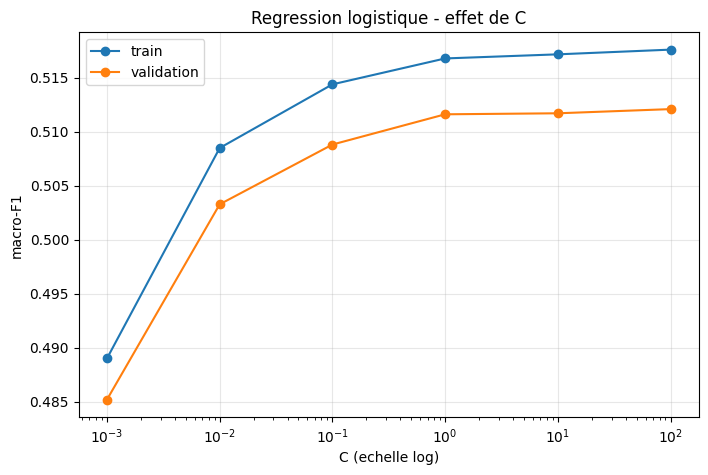

Meilleurs parametres : {'C': 100}
Meilleur macro-F1 (CV) : 0.512


In [19]:
lr_params = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

lr_model = GridSearchCV(
    LogisticRegression(max_iter=2000, solver="lbfgs",
                       penalty="l2", class_weight="balanced"),
    param_grid=lr_params, scoring="f1_macro", cv=3, n_jobs=-1, verbose=1)
lr_model.fit(X_train_scaled, y_train)          # LR -> donnees STANDARDISEES

# Courbe biais-variance : effet de C
C_range = [0.001, 0.01, 0.1, 1, 10, 100]
tr, va = validation_curve(
    LogisticRegression(max_iter=2000, class_weight="balanced"),
    X_train_scaled, y_train, param_name="C", param_range=C_range,
    cv=3, scoring="f1_macro", n_jobs=-1)
plt.figure(figsize=(8, 5))
plt.plot(C_range, tr.mean(1), "o-", label="train")
plt.plot(C_range, va.mean(1), "o-", label="validation")
plt.xscale("log"); plt.xlabel("C (echelle log)"); plt.ylabel("macro-F1")
plt.title("Regression logistique - effet de C"); plt.legend(); plt.grid(alpha=0.3); plt.show()

print("Meilleurs parametres :", lr_model.best_params_)
print(f"Meilleur macro-F1 (CV) : {lr_model.best_score_:.3f}")

Validation set performance :

Accuracy             : 0.6051
Macro-F1   (cle ici) : 0.4979
Weighted-F1          : 0.6337
Precision (weighted) : 0.7087
Recall    (weighted) : 0.6051


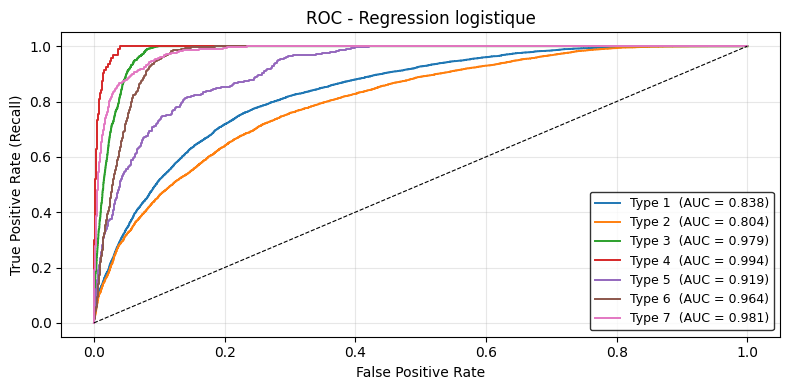

In [20]:
print("Validation set performance :\n")
predict(lr_model, X_valid_scaled, y_valid)
plot_roc_curves(lr_model.best_estimator_, X_valid_scaled, y_valid,
                "ROC - Regression logistique")

## 7.2 Support Vector Classifier

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Recherche : 261.6 s | Meilleurs parametres : {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Meilleur macro-F1 (CV) : 0.725


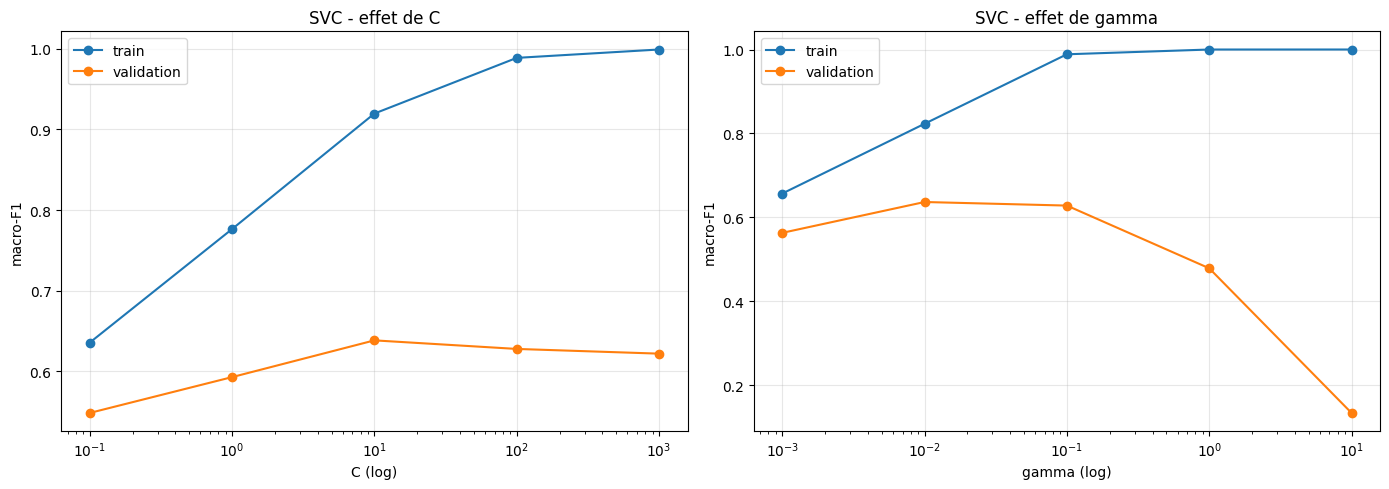

In [21]:
svc_params = {'kernel': ['rbf'], 'C': [1, 10, 100], 'gamma': [0.01, 0.1, 'scale']}

# Sous-echantillon (le SVC RBF ne passe pas a l'echelle) -- donnees STANDARDISEES
X_sub, _, y_sub, _ = train_test_split(
    X_train_scaled, y_train, train_size=20000, stratify=y_train, random_state=42)

svc_model = GridSearchCV(SVC(class_weight="balanced"), param_grid=svc_params,
                         scoring="f1_macro", cv=3, n_jobs=-1, verbose=1)
t0 = time.perf_counter(); svc_model.fit(X_sub, y_sub); search_time = time.perf_counter() - t0
print(f"Recherche : {search_time:.1f} s | Meilleurs parametres : {svc_model.best_params_}")
print(f"Meilleur macro-F1 (CV) : {svc_model.best_score_:.3f}")

# Modele final : probability=True pour les courbes ROC
best = svc_model.best_params_
best_svc = SVC(class_weight="balanced", probability=True, random_state=42, **best).fit(X_sub, y_sub)

# Courbes biais-variance (echantillon reduit)
X_vc, _, y_vc, _ = train_test_split(X_train_scaled, y_train, train_size=8000,
                                    stratify=y_train, random_state=42)
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for ax, (pname, prange, fixed) in zip(axs, [
        ("C",     [0.1, 1, 10, 100, 1000], dict(gamma=best['gamma'])),
        ("gamma", [0.001, 0.01, 0.1, 1, 10], dict(C=best['C']))]):
    tr, va = validation_curve(SVC(kernel="rbf", class_weight="balanced", **fixed),
                              X_vc, y_vc, param_name=pname, param_range=prange,
                              cv=3, scoring="f1_macro", n_jobs=-1)
    ax.plot(prange, tr.mean(1), "o-", label="train")
    ax.plot(prange, va.mean(1), "o-", label="validation")
    ax.set_xscale("log"); ax.set_xlabel(f"{pname} (log)"); ax.set_ylabel("macro-F1")
    ax.set_title(f"SVC - effet de {pname}"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Validation set performance :

Accuracy             : 0.8436
Macro-F1   (cle ici) : 0.7493
Weighted-F1          : 0.8440
Precision (weighted) : 0.8448
Recall    (weighted) : 0.8436


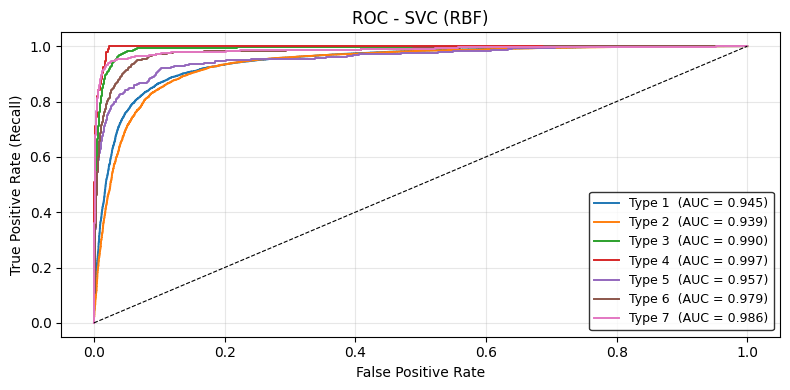

In [22]:
print("Validation set performance :\n")
predict(best_svc, X_valid_scaled, y_valid)
plot_roc_curves(best_svc, X_valid_scaled, y_valid, "ROC - SVC (RBF)")

## 7.3 K-Nearest Neighbors

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Temps : 264.5 s | Meilleurs parametres : {'n_neighbors': 5, 'weights': 'distance'}
Meilleur macro-F1 (CV) : 0.785


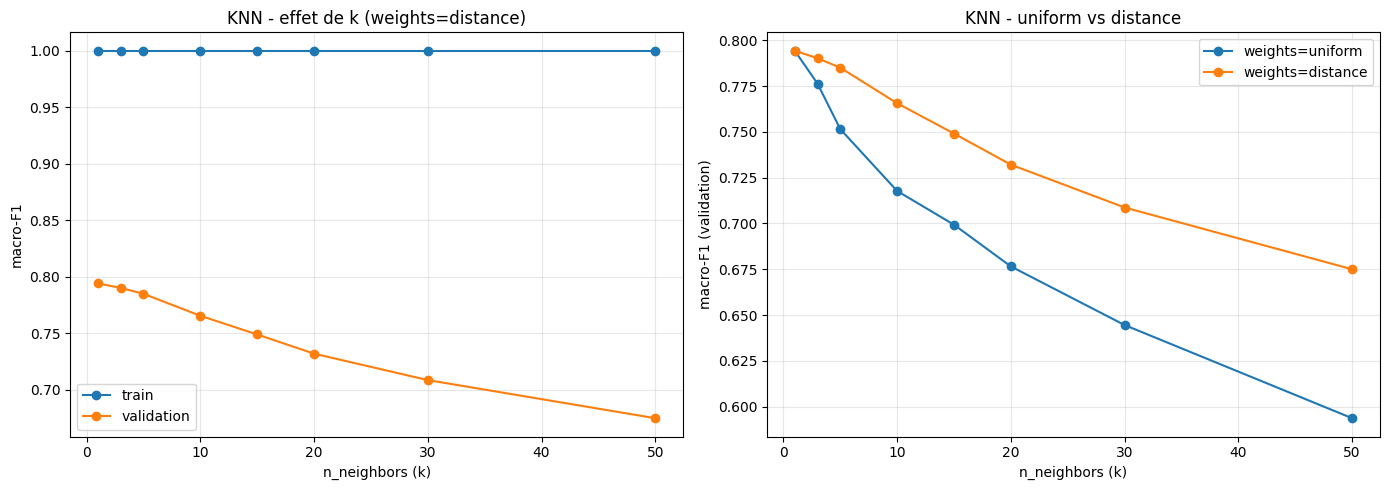

In [24]:
knn_params = {"n_neighbors": list(range(5, 20)),
              "weights": ["uniform", "distance"]}

knn_model = GridSearchCV(KNeighborsClassifier(n_jobs=-1), param_grid=knn_params,
                         scoring="f1_macro", cv=3, verbose=1)
t0 = time.perf_counter(); knn_model.fit(X_train_scaled, y_train)   # KNN -> STANDARDISEES
print(f"Temps : {time.perf_counter()-t0:.1f} s | Meilleurs parametres : {knn_model.best_params_}")
print(f"Meilleur macro-F1 (CV) : {knn_model.best_score_:.3f}")

best = knn_model.best_params_
k_range = [1, 3, 5, 10, 15, 20, 30, 50]
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
tr, va = validation_curve(KNeighborsClassifier(weights=best['weights'], n_jobs=-1),
                          X_train_scaled, y_train, param_name="n_neighbors",
                          param_range=k_range, cv=3, scoring="f1_macro")
axs[0].plot(k_range, tr.mean(1), "o-", label="train")
axs[0].plot(k_range, va.mean(1), "o-", label="validation")
axs[0].set_xlabel("n_neighbors (k)"); axs[0].set_ylabel("macro-F1")
axs[0].set_title(f"KNN - effet de k (weights={best['weights']})"); axs[0].legend(); axs[0].grid(alpha=0.3)
for w in ["uniform", "distance"]:
    _, va_w = validation_curve(KNeighborsClassifier(weights=w, n_jobs=-1),
                               X_train_scaled, y_train, param_name="n_neighbors",
                               param_range=k_range, cv=3, scoring="f1_macro")
    axs[1].plot(k_range, va_w.mean(1), "o-", label=f"weights={w}")
axs[1].set_xlabel("n_neighbors (k)"); axs[1].set_ylabel("macro-F1 (validation)")
axs[1].set_title("KNN - uniform vs distance"); axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Validation set performance :

Accuracy             : 0.8841
Macro-F1   (cle ici) : 0.8062
Weighted-F1          : 0.8836
Precision (weighted) : 0.8835
Recall    (weighted) : 0.8841


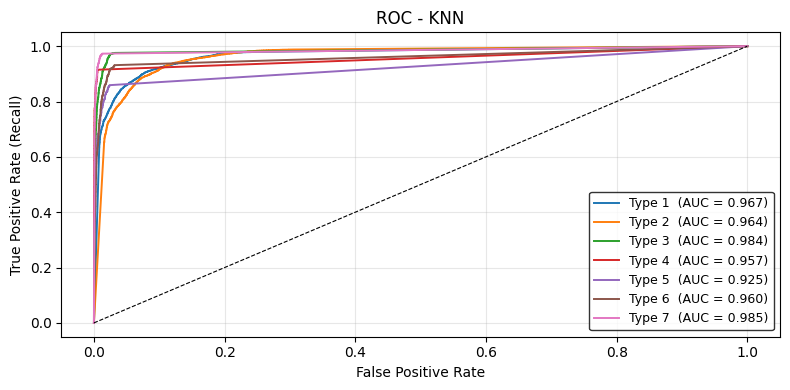

In [25]:
print("Validation set performance :\n")
predict(knn_model, X_valid_scaled, y_valid)
plot_roc_curves(knn_model.best_estimator_, X_valid_scaled, y_valid, "ROC - KNN")

## 7.4 Decision Tree Classifier

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Temps : 263.2 s | Meilleurs parametres : {'class_weight': None, 'criterion': 'entropy', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Meilleur macro-F1 (CV) : 0.770


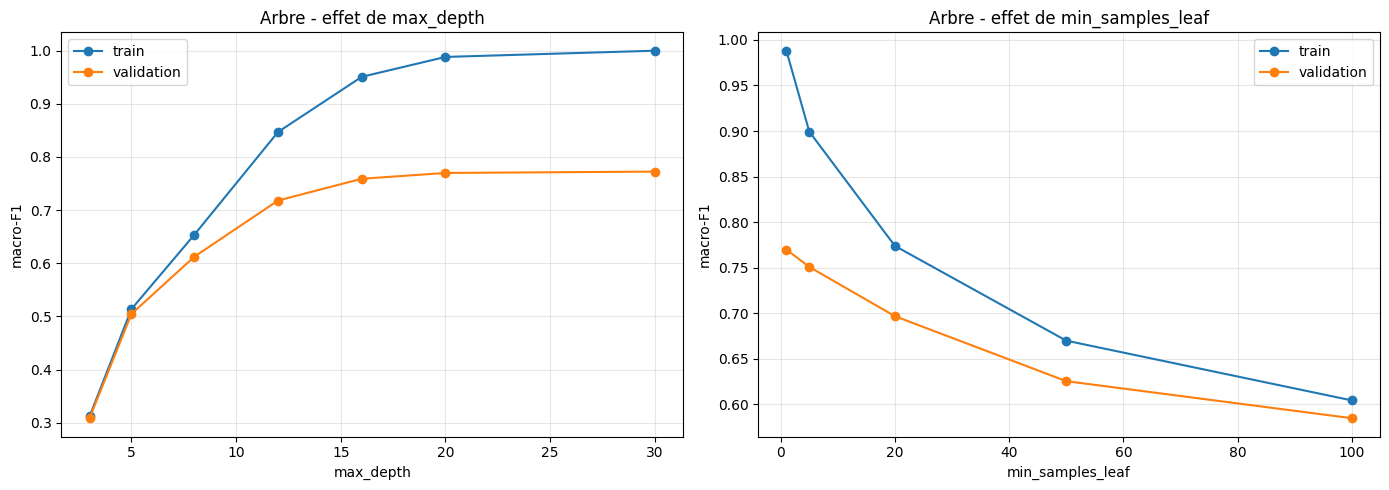

In [26]:
dtc_params = {"criterion": ["entropy", "gini"],
              "max_depth": [8, 12, 16, 20],
              "min_samples_leaf": [1, 2, 4],
              "min_samples_split": [2, 4, 8],
              "max_features": [8, 12, None],
              "class_weight": [None, "balanced"]}

dtc_model = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid=dtc_params,
                         scoring="f1_macro", cv=3, n_jobs=-1, verbose=1)
t0 = time.perf_counter(); dtc_model.fit(X_train, y_train)          # ARBRE -> DONNEES BRUTES
print(f"Temps : {time.perf_counter()-t0:.1f} s | Meilleurs parametres : {dtc_model.best_params_}")
print(f"Meilleur macro-F1 (CV) : {dtc_model.best_score_:.3f}")

best = dtc_model.best_params_
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
depth_range = [3, 5, 8, 12, 16, 20, 30]
tr, va = validation_curve(
    DecisionTreeClassifier(criterion=best['criterion'], min_samples_leaf=best['min_samples_leaf'],
                           min_samples_split=best['min_samples_split'], max_features=best['max_features'],
                           class_weight=best['class_weight'], random_state=42),
    X_train, y_train, param_name="max_depth", param_range=depth_range, cv=3, scoring="f1_macro")
axs[0].plot(depth_range, tr.mean(1), "o-", label="train"); axs[0].plot(depth_range, va.mean(1), "o-", label="validation")
axs[0].set_xlabel("max_depth"); axs[0].set_ylabel("macro-F1"); axs[0].set_title("Arbre - effet de max_depth")
axs[0].legend(); axs[0].grid(alpha=0.3)
leaf_range = [1, 5, 20, 50, 100]
tr, va = validation_curve(
    DecisionTreeClassifier(criterion=best['criterion'], max_depth=best['max_depth'],
                           min_samples_split=best['min_samples_split'], max_features=best['max_features'],
                           class_weight=best['class_weight'], random_state=42),
    X_train, y_train, param_name="min_samples_leaf", param_range=leaf_range, cv=3, scoring="f1_macro")
axs[1].plot(leaf_range, tr.mean(1), "o-", label="train"); axs[1].plot(leaf_range, va.mean(1), "o-", label="validation")
axs[1].set_xlabel("min_samples_leaf"); axs[1].set_ylabel("macro-F1"); axs[1].set_title("Arbre - effet de min_samples_leaf")
axs[1].legend(); axs[1].grid(alpha=0.3); plt.tight_layout(); plt.show()

Validation set performance :

Accuracy             : 0.8676
Macro-F1   (cle ici) : 0.8005
Weighted-F1          : 0.8673
Precision (weighted) : 0.8674
Recall    (weighted) : 0.8676


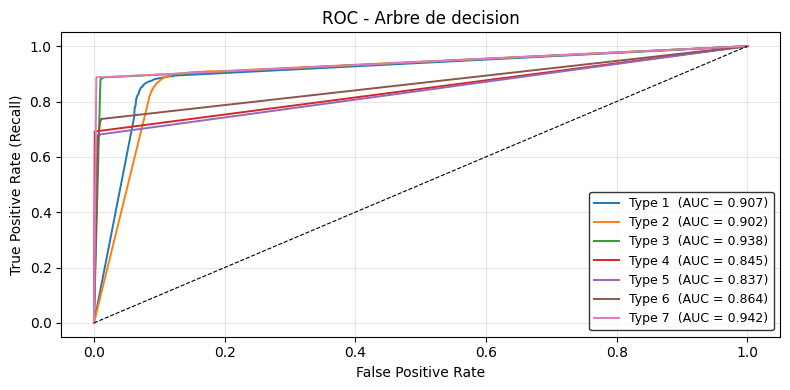

In [27]:
print("Validation set performance :\n")
predict(dtc_model, X_valid, y_valid)
plot_roc_curves(dtc_model.best_estimator_, X_valid, y_valid, "ROC - Arbre de decision")

## 7.5 Random Forest Classifier

Forêt entraînée sur **données brutes**, avec `class_weight="balanced"` pour le déséquilibre et des arbres **profonds** (`max_depth` large/illimité) : chaque arbre surapprend, le vote de l'ensemble corrige. C'est l'inverse de l'arbre seul qu'il faut brider.

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Temps : 1234.9 s | Meilleurs parametres : {'max_depth': None, 'max_features': 0.5, 'n_estimators': 300}
Meilleur macro-F1 (CV) : 0.848


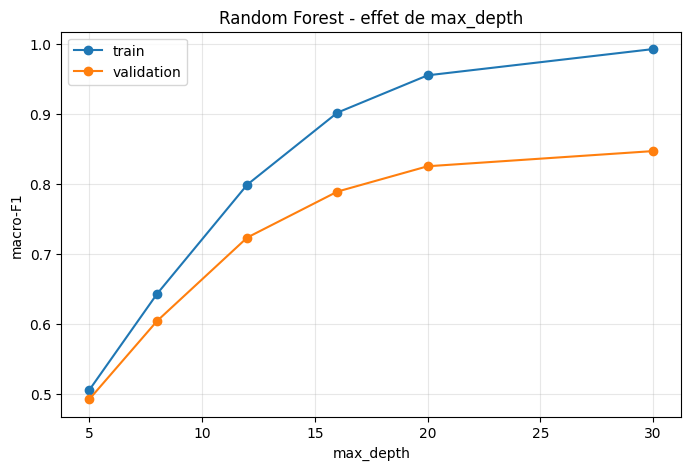

In [28]:
rfc_params = {
    "n_estimators": [200, 300],
    "max_depth":    [20, 30, None],
    "max_features": ["sqrt", 0.5],
}
rfc_model = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=1),
    param_grid=rfc_params, scoring="f1_macro", cv=3, n_jobs=-1, verbose=1)
t0 = time.perf_counter(); rfc_model.fit(X_train, y_train)          # RF -> DONNEES BRUTES
print(f"Temps : {time.perf_counter()-t0:.1f} s | Meilleurs parametres : {rfc_model.best_params_}")
print(f"Meilleur macro-F1 (CV) : {rfc_model.best_score_:.3f}")

best_rfc = rfc_model.best_estimator_
# Courbe biais-variance : effet de max_depth
depth_range = [5, 8, 12, 16, 20, 30]
tr, va = validation_curve(
    RandomForestClassifier(n_estimators=best_rfc.n_estimators, max_features=best_rfc.max_features,
                           class_weight="balanced", random_state=42, n_jobs=-1),
    X_train, y_train, param_name="max_depth", param_range=depth_range, cv=3, scoring="f1_macro")
plt.figure(figsize=(8, 5))
plt.plot(depth_range, tr.mean(1), "o-", label="train")
plt.plot(depth_range, va.mean(1), "o-", label="validation")
plt.xlabel("max_depth"); plt.ylabel("macro-F1"); plt.title("Random Forest - effet de max_depth")
plt.legend(); plt.grid(alpha=0.3); plt.show()

Validation set performance :

Accuracy             : 0.9283
Macro-F1   (cle ici) : 0.8669
Weighted-F1          : 0.9275
Precision (weighted) : 0.9281
Recall    (weighted) : 0.9283


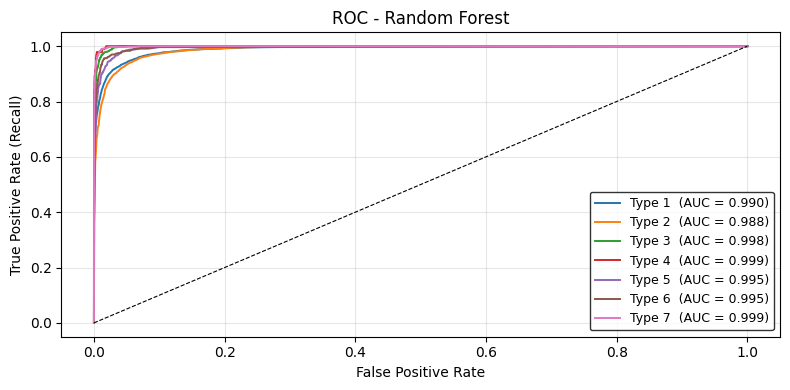

In [29]:
print("Validation set performance :\n")
predict(best_rfc, X_valid, y_valid)
plot_roc_curves(best_rfc, X_valid, y_valid, "ROC - Random Forest")

## 7.6 XGBoost

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Temps : 396.1 s | Meilleurs parametres : {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 300}
Meilleur macro-F1 (CV) : 0.876


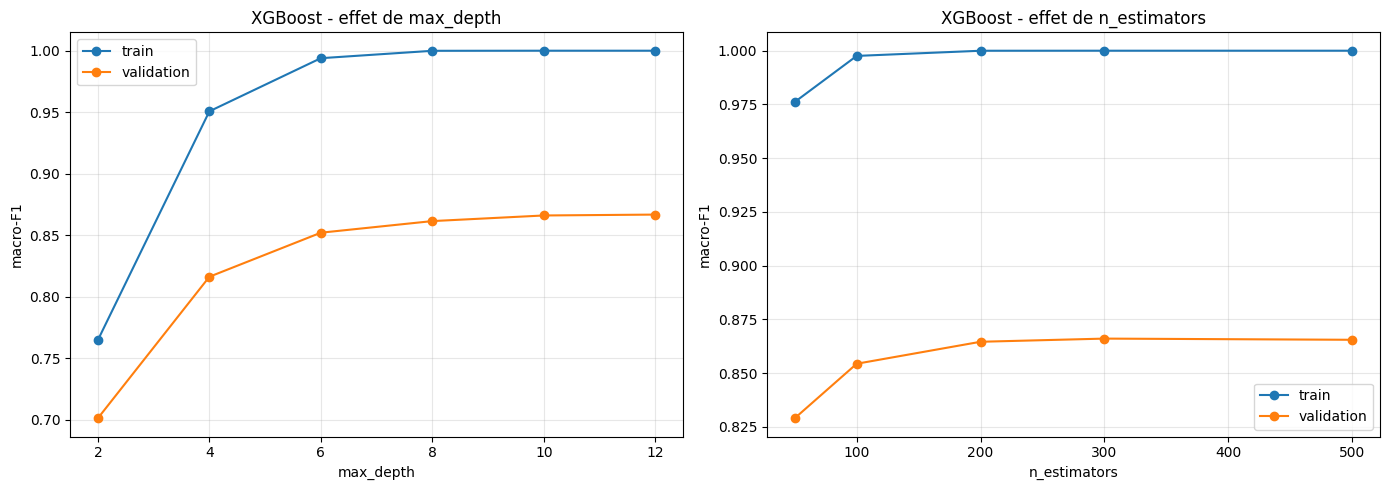

In [8]:
xgb_params = {'max_depth': [6, 8, 10],
              'n_estimators': [200, 300],
              'learning_rate': [0.1, 0.2]}

# Pondiration des classes via sample_weight (equivalent de class_weight='balanced')
sw_train = compute_sample_weight("balanced", y_train)

xgb_model = GridSearchCV(
    XGBClassifier(tree_method="hist", n_jobs=1, random_state=42,
                  objective="multi:softprob", num_class=7),
    param_grid=xgb_params, scoring="f1_macro", cv=3, n_jobs=-1, verbose=1)
t0 = time.perf_counter()
xgb_model.fit(X_train, y_train, sample_weight=sw_train)            # XGB -> DONNEES BRUTES (0..6)
print(f"Temps : {time.perf_counter()-t0:.1f} s | Meilleurs parametres : {xgb_model.best_params_}")
print(f"Meilleur macro-F1 (CV) : {xgb_model.best_score_:.3f}")
best_xgb = xgb_model.best_estimator_

# Courbes biais-variance
best = xgb_model.best_params_
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for ax, (pname, prange, fixed) in zip(axs, [
        ("max_depth",    [2, 4, 6, 8, 10, 12], dict(n_estimators=best['n_estimators'], learning_rate=best['learning_rate'])),
        ("n_estimators", [50, 100, 200, 300, 500], dict(max_depth=best['max_depth'], learning_rate=best['learning_rate']))]):
    tr, va = validation_curve(XGBClassifier(tree_method="hist", n_jobs=-1, random_state=42, **fixed),
                              X_train, y_train, param_name=pname, param_range=prange,
                              cv=3, scoring="f1_macro")
    ax.plot(prange, tr.mean(1), "o-", label="train"); ax.plot(prange, va.mean(1), "o-", label="validation")
    ax.set_xlabel(pname); ax.set_ylabel("macro-F1"); ax.set_title(f"XGBoost - effet de {pname}")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Validation set performance :

Accuracy             : 0.9317
Macro-F1   (cle ici) : 0.8963
Weighted-F1          : 0.9317
Precision (weighted) : 0.9318
Recall    (weighted) : 0.9317


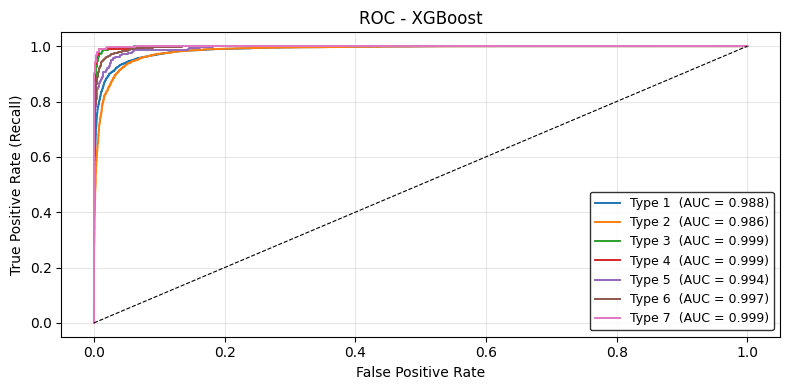

In [9]:
print("Validation set performance :\n")
predict(best_xgb, X_valid, y_valid)
plot_roc_curves(best_xgb, X_valid, y_valid, "ROC - XGBoost")

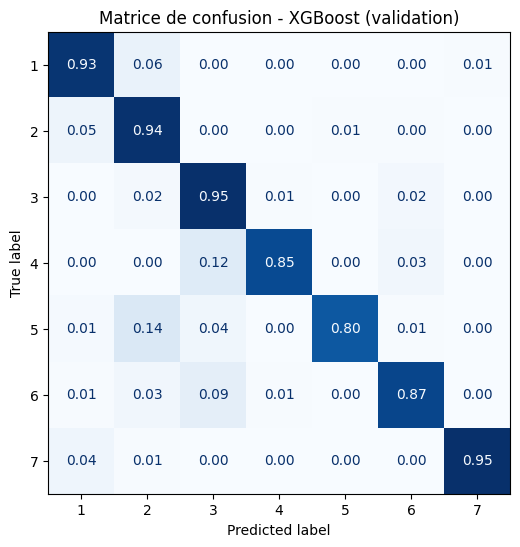

In [32]:
plot_confusion_matrix(best_xgb, X_valid, y_valid,
                      "Matrice de confusion - XGBoost (validation)", normalize="true")

### Insights:

**Le modèle est juste la plupart du temps** — la diagonale foncée montre que toutes les classes sont bien prédites, entre 0.80 et 0.95. Lecture : chaque ligne se lit « parmi les vrais type X, quelle proportion a été bien classée » (c'est le recall par classe).

**Les grosses classes sont presque parfaites.** Types 1, 2, 3 et 7 entre 0.93 et 0.95. La fameuse confusion 1↔2 existe encore mais reste petite (6 % et 5 %) — bien plus maîtrisée qu'on pouvait le craindre.

**Les deux classes rares restent les plus dures, mais s'en sortent honorablement** grâce à la pondération :
- **Type 4 à 0.85**, avec 12 % confondus avec le type 3 (forêts de basse altitude qui se ressemblent).
- **Type 5 à 0.80**, avec 14 % confondus avec le type 2 (sa classe voisine, énorme).

**Le mécanisme est toujours le même : le modèle « absorbe » une classe rare dans la grande classe voisine qui lui ressemble** (5→2, 4→3). Mais par rapport à la version sans pondération, les rares ne s'effondrent plus à 0.6 — elles tiennent à 0.80-0.85. C'est exactement le bénéfice de `class_weight` / `sample_weight`, et c'est ce qui fait remonter le macro-F1 à 0.896.

**En résumé :** le modèle excelle sur les grosses classes et reste solide sur les petites. L'écart entre macro-F1 (0.896) et accuracy (0.93) tient uniquement aux types 4 et 5 — et il s'est nettement resserré.

## 7.7 LightGBM

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Temps : 360.0 s | Meilleurs parametres : {'max_depth': 10, 'n_estimators': 300, 'num_leaves': 64}
Meilleur macro-F1 (CV) : 0.874


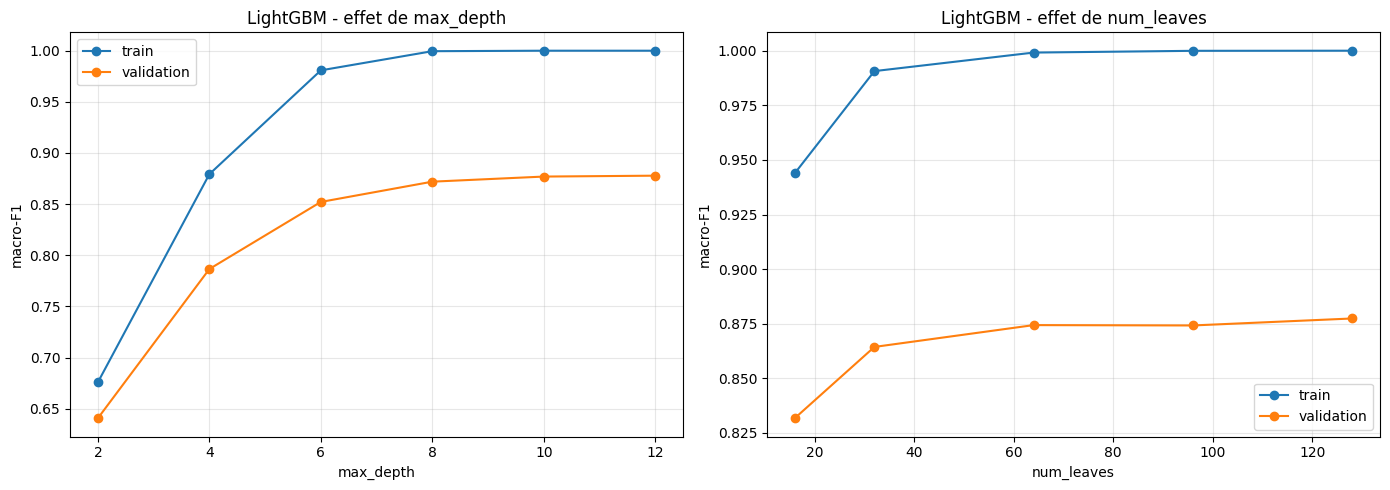

In [33]:
lgm_params = {'n_estimators': [200, 300],
              'max_depth': [6, 8, 10],
              'num_leaves': [32, 64, 96]}

lgm_model = GridSearchCV(
    LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=1, verbose=-1),
    param_grid=lgm_params, scoring="f1_macro", cv=3, n_jobs=-1, verbose=1)
t0 = time.perf_counter(); lgm_model.fit(X_train, y_train)          # LGBM -> DONNEES BRUTES
print(f"Temps : {time.perf_counter()-t0:.1f} s | Meilleurs parametres : {lgm_model.best_params_}")
print(f"Meilleur macro-F1 (CV) : {lgm_model.best_score_:.3f}")
best_lgm = lgm_model.best_estimator_

best = lgm_model.best_params_
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
depth_range = [2, 4, 6, 8, 10, 12]
tr, va = validation_curve(
    LGBMClassifier(n_estimators=best['n_estimators'], num_leaves=255, class_weight="balanced",
                   random_state=42, n_jobs=-1, verbose=-1),
    X_train, y_train, param_name="max_depth", param_range=depth_range, cv=3, scoring="f1_macro")
axs[0].plot(depth_range, tr.mean(1), "o-", label="train"); axs[0].plot(depth_range, va.mean(1), "o-", label="validation")
axs[0].set_xlabel("max_depth"); axs[0].set_ylabel("macro-F1"); axs[0].set_title("LightGBM - effet de max_depth")
axs[0].legend(); axs[0].grid(alpha=0.3)
leaves_range = [16, 32, 64, 96, 128]
tr, va = validation_curve(
    LGBMClassifier(n_estimators=best['n_estimators'], max_depth=best['max_depth'], class_weight="balanced",
                   random_state=42, n_jobs=-1, verbose=-1),
    X_train, y_train, param_name="num_leaves", param_range=leaves_range, cv=3, scoring="f1_macro")
axs[1].plot(leaves_range, tr.mean(1), "o-", label="train"); axs[1].plot(leaves_range, va.mean(1), "o-", label="validation")
axs[1].set_xlabel("num_leaves"); axs[1].set_ylabel("macro-F1"); axs[1].set_title("LightGBM - effet de num_leaves")
axs[1].legend(); axs[1].grid(alpha=0.3); plt.tight_layout(); plt.show()

Validation set performance :

Accuracy             : 0.9272
Macro-F1   (cle ici) : 0.8930
Weighted-F1          : 0.9272
Precision (weighted) : 0.9272
Recall    (weighted) : 0.9272


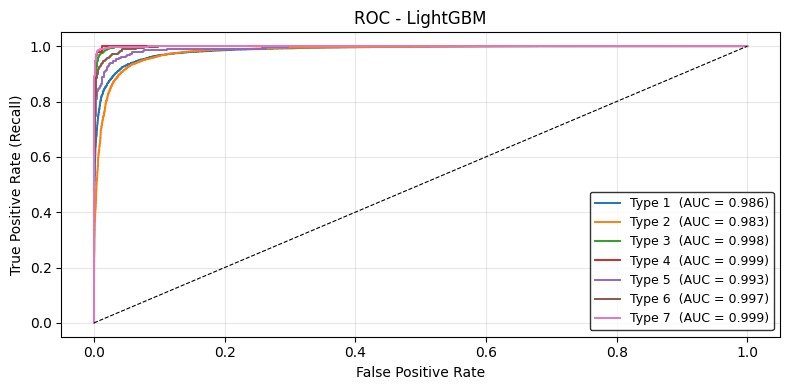

In [34]:
print("Validation set performance :\n")
predict(best_lgm, X_valid, y_valid)
plot_roc_curves(best_lgm, X_valid, y_valid, "ROC - LightGBM")

## 7.8 Summary statistics

In [35]:
# Chaque modele est evalue sur le bon X_valid : standardise pour LR/SVC/KNN, brut pour les arbres
models = {
    "Logistic Regression": (lr_model.best_estimator_,  X_valid_scaled),
    "SVC":                  (best_svc,                 X_valid_scaled),
    "KNN":                  (knn_model.best_estimator_, X_valid_scaled),
    "Decision Tree":        (dtc_model.best_estimator_, X_valid),
    "Random Forest":        (best_rfc,                 X_valid),
    "XGBoost":              (best_xgb,                 X_valid),
    "LightGBM":             (best_lgm,                 X_valid),
}

rows = []
for name, (model, Xv) in models.items():
    m = get_metrics(model, Xv, y_valid)
    rows.append({"model": name, **m})

summary_table = (pd.DataFrame(rows).set_index("model")
                 [["accuracy", "macro_f1", "weighted_f1", "precision", "recall"]]
                 .sort_values("macro_f1", ascending=False).round(3))
summary_table

,accuracy,macro_f1,weighted_f1,precision,recall
model,,,,,
XGBoost,0.932,0.896,0.932,0.932,0.932
LightGBM,0.927,0.893,0.927,0.927,0.927
Random Forest,0.928,0.867,0.927,0.928,0.928
KNN,0.884,0.806,0.884,0.883,0.884
Decision Tree,0.868,0.801,0.867,0.867,0.868
SVC,0.844,0.749,0.844,0.845,0.844
Logistic Regression,0.605,0.498,0.634,0.709,0.605


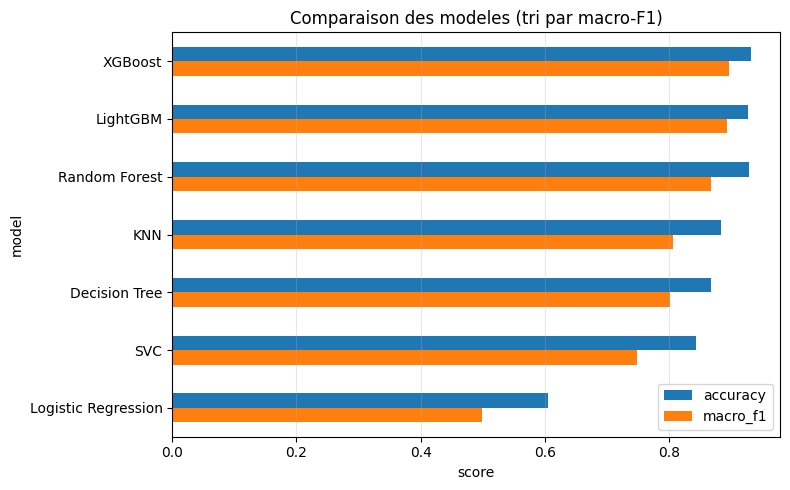

In [36]:
summary_table[["accuracy", "macro_f1"]].plot.barh(figsize=(8, 5))
plt.xlabel("score"); plt.title("Comparaison des modeles (tri par macro-F1)")
plt.gca().invert_yaxis(); plt.grid(axis="x", alpha=0.3); plt.tight_layout(); plt.show()

### Insights:

**Les trois méthodes d'ensemble dominent nettement et sont au coude à coude :** XGBoost (macro-F1 0.896), LightGBM (0.893) et Random Forest (0.867). Les deux boosting sont quasi indistinguables ; la forêt suit d'un cran.

**Ensuite un palier en dessous :** le KNN (0.806) et l'arbre seul (0.801), à égalité. Puis le SVC (0.749), correct mais coûteux et entraîné sur sous-échantillon seulement.

**Et tout en bas, la régression logistique (0.498) :** trop simple pour ces données non linéaires. C'est elle qui révèle le mieux l'intérêt du macro-F1.

**La comparaison accuracy vs macro_f1 raconte l'histoire des classes rares.** Pour les bons modèles, l'écart est petit (XGBoost : 0.932 vs 0.896) — ils gèrent correctement les types 4 et 5. Pour la régression logistique, l'écart est énorme (0.605 vs 0.498) : elle rate complètement les petites classes, et le macro-F1 la sanctionne là où l'accuracy la flattait encore.

**Un détail parlant sur la régression logistique :** sa precision (0.709) est bien plus haute que son recall et son accuracy (0.605). Avec `class_weight="balanced"`, elle tente d'attraper les classes rares mais se trompe souvent en le faisant — signe qu'une frontière linéaire ne suffit pas, même bien intentionnée.

**Le message global :** sur ces données, il faut **combiner plusieurs arbres** (forêt ou boosting) pour bien faire, et le **boosting tient la première place**. Un seul arbre ou un modèle linéaire reste loin derrière. XGBoost est désigné champion pour le test final.

## 7.9 PCA

In [37]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
print(f"PCA : {X_train_scaled.shape[1]} -> {X_train_pca.shape[1]} dimensions (95% de variance)")

PCA : 63 -> 44 dimensions (95% de variance)


In [38]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("svc", SVC(kernel="rbf", class_weight="balanced")),
])
param_grid = {
    "pca__n_components": [0.90, 0.95, 0.99],
    "svc__C": [1, 10, 100],
    "svc__gamma": [0.01, 0.1, "scale"],
}
# Sous-echantillon (X_train BRUT : le scaler est dans le pipeline)
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=20000,
                                      stratify=y_train, random_state=42)
search = GridSearchCV(pipe, param_grid, scoring="f1_macro", cv=3, n_jobs=-1, verbose=1)
t0 = time.perf_counter(); search.fit(X_sub, y_sub)
print(f"Recherche : {time.perf_counter()-t0:.1f} s | Meilleurs parametres : {search.best_params_}")
print(f"Meilleur macro-F1 (CV) : {search.best_score_:.3f}")

best_pipe = search.best_estimator_
print("\nValidation :")
predict(best_pipe, X_valid, y_valid)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Recherche : 585.9 s | Meilleurs parametres : {'pca__n_components': 0.99, 'svc__C': 100, 'svc__gamma': 0.1}
Meilleur macro-F1 (CV) : 0.716

Validation :
Accuracy             : 0.8426
Macro-F1   (cle ici) : 0.7505
Weighted-F1          : 0.8430
Precision (weighted) : 0.8438
Recall    (weighted) : 0.8426


array([2, 1, 1, ..., 2, 0, 0], shape=(20000,), dtype=int32)

### Insights:

**La PCA n'a presque rien compressé : 63 → 44 dimensions pour garder 95 % de la variance**, et le meilleur réglage retenu monte même à 99 % de variance (donc encore plus de composantes). C'est déjà un signal : le modèle « veut » conserver presque toute l'information. Après le feature engineering, il reste peu de redondance forte à éliminer.

**Résultat : macro-F1 ≈ 0.75, accuracy ≈ 0.84 — quasiment identique au SVC sans PCA (0.749 / 0.844).** La PCA n'a donc apporté **aucune amélioration** : elle a juste reformulé les variables sans rien ajouter ni vraiment simplifier.

**Et elle reste lente** (~10 minutes à cause du SVC) : comme elle n'a presque rien réduit, elle n'a même pas fait gagner de temps de calcul. Le compromis est perdant sur tous les tableaux.

la PCA est utile quand les variables se répètent beaucoup (très corrélées) — ce n'est pas le cas ici.

# 8. Traitement du déséquilibre : pondération vs SMOTENC

On compare trois stratégies sur le **même modèle** (XGBoost, tree_method `hist`), à hyperparamètres fixés :

1. **Baseline** — aucun traitement ;
2. **Pondération** — `sample_weight="balanced"` (poids inversement proportionnel à la fréquence) ;
3. **SMOTENC** — sur-échantillonnage synthétique des classes minoritaires, en version *NC* (Nominal-Continuous) car le jeu mélange variables continues et indicatrices one-hot (un SMOTE classique interpolerait des indicatrices, ce qui n'a pas de sens).

La métrique qui nous intéresse n'est pas l'accuracy globale (que la baseline maximise mécaniquement) mais le **macro-F1** et surtout le **recall des classes rares 4 et 5**.

In [39]:
xgb_hp = dict(max_depth=8, n_estimators=300, learning_rate=0.1,
              tree_method="hist", n_jobs=-1, random_state=42)

def recall_per_class(model, Xv, yv, classes=(3, 4)):   # 0-index : 3->type4, 4->type5
    yp = model.predict(Xv)
    cm = confusion_matrix(yv, yp)
    rec = cm.diagonal() / cm.sum(axis=1)
    return {f"recall_type{c+1}": round(rec[c], 3) for c in classes}

results = []

# 1) Baseline
m = XGBClassifier(**xgb_hp).fit(X_train, y_train)
results.append({"strategie": "baseline", **get_metrics(m, X_valid, y_valid), **recall_per_class(m, X_valid, y_valid)})

# 2) Ponderation
sw = compute_sample_weight("balanced", y_train)
m = XGBClassifier(**xgb_hp).fit(X_train, y_train, sample_weight=sw)
results.append({"strategie": "ponderation", **get_metrics(m, X_valid, y_valid), **recall_per_class(m, X_valid, y_valid)})

# 3) SMOTENC (sur le train uniquement)
sm = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=5)
X_res, y_res = sm.fit_resample(X_train, y_train)
print("SMOTENC :", X_train.shape[0], "->", X_res.shape[0], "lignes |",
      "classes equilibrees :", np.bincount(y_res))
m = XGBClassifier(**xgb_hp).fit(X_res, y_res)
results.append({"strategie": "SMOTENC", **get_metrics(m, X_valid, y_valid), **recall_per_class(m, X_valid, y_valid)})

imb_table = (pd.DataFrame(results).set_index("strategie")
             [["accuracy", "macro_f1", "recall_type4", "recall_type5"]].round(3))
imb_table

SMOTENC : 60000 -> 204792 lignes | classes equilibrees : [29256 29256 29256 29256 29256 29256 29256]


,accuracy,macro_f1,recall_type4,recall_type5
strategie,,,,
baseline,0.917,0.873,0.787,0.642
ponderation,0.904,0.874,0.840,0.838
SMOTENC,0.903,0.873,0.894,0.792


### Insights:

**SMOTENC a fait passer le train de 60 000 à ~205 000 lignes**, en fabriquant des exemples synthétiques jusqu'à ce que les 7 classes aient le même effectif (29 256 chacune). Les deux autres stratégies gardent les 60 000 lignes d'origine.

**Le tableau montre exactement l'arbitrage attendu :**

| Stratégie | Accuracy | Macro-F1 | Recall type 4 | Recall type 5 |
|---|---|---|---|---|
| Baseline | **0.917** | 0.873 | 0.787 | 0.642 |
| Pondération | 0.904 | **0.874** | 0.840 | **0.838** |
| SMOTENC | 0.903 | 0.873 | **0.894** | 0.792 |

**La baseline gagne sur l'accuracy mais perd sur les classes rares.** Elle maximise le score global (0.917) en soignant les grosses classes, mais laisse le type 5 sous-détecté (recall 0.64). C'est précisément le piège que le macro-F1 sert à révéler.

**Pondération et SMOTENC sacrifient ~1,5 point d'accuracy pour bien mieux attraper les rares.** Le recall du type 5 bondit de 0.64 à ~0.79-0.84, celui du type 4 de 0.79 à 0.84-0.89. C'est exactement l'objectif quand le déséquilibre est le problème central.

**Détail intéressant : le macro-F1 reste quasi identique (~0.873) pour les trois.** Le recall des classes rares monte fort, mais le F1 combine recall *et* precision — en attrapant plus de types 4/5, on génère aussi quelques fausses alertes, ce qui compense. Le gain est donc réel sur la *détection*, plus discret sur le F1 global.

**Conclusion — le choix dépend du coût métier :**
- Si rater une forêt rare coûte cher (ex. espèce à surveiller) → **pondération** : presque aussi bonne que SMOTENC sur les rares, gratuite, sans données synthétiques, et la plus rapide.
- SMOTENC pousse le recall du type 4 le plus haut (0.89), mais au prix de 3,4× plus de données et donc d'un entraînement plus lourd.
- Si seul le pourcentage global compte → la baseline suffit.

Pour ce projet, la **pondération** est le meilleur compromis : le gain sur les rares est quasi maximal, sans le coût de SMOTENC.

# 9. Stacking : RF + XGBoost + LightGBM

On empile les trois modèles d'ensemble (tous à base d'arbres, donc **données brutes**) avec une **régression logistique** comme méta-modèle, entraînée sur les probabilités *out-of-fold* des trois bases (`cv=3`, pas de fuite). L'idée : si les trois modèles se trompent sur des points différents, le méta-modèle apprend à arbitrer.

Temps d'entrainement : 216.5 s

Validation set performance :

Accuracy             : 0.9203
Macro-F1   (cle ici) : 0.8610
Weighted-F1          : 0.9217
Precision (weighted) : 0.9253
Recall    (weighted) : 0.9203


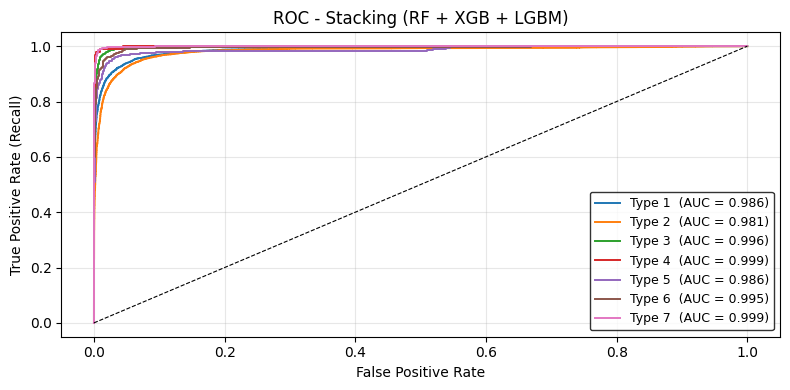

In [40]:
estimators = [
    ("rf",   RandomForestClassifier(n_estimators=300, max_depth=None,
                                    class_weight="balanced", random_state=42, n_jobs=-1)),
    ("xgb",  XGBClassifier(max_depth=8, n_estimators=300, learning_rate=0.1,
                           tree_method="hist", random_state=42, n_jobs=-1)),
    ("lgbm", LGBMClassifier(n_estimators=300, max_depth=8, num_leaves=64,
                            class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)),
]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced"),
    stack_method="predict_proba", cv=3, n_jobs=-1, passthrough=False)

t0 = time.perf_counter(); stack.fit(X_train, y_train)
print(f"Temps d'entrainement : {time.perf_counter()-t0:.1f} s\n")
print("Validation set performance :\n")
predict(stack, X_valid, y_valid)
plot_roc_curves(stack, X_valid, y_valid, "ROC - Stacking (RF + XGB + LGBM)")

### Insights:

**La ROC est au sommet, comme les modèles d'ensemble individuels :** tout entre 0.981 et 0.999. Aucune surprise — le stacking hérite de la qualité de ses trois bases.

**Mais le verdict tombe sur le macro-F1 : 0.861 — *en dessous* de XGBoost seul (0.896) et de LightGBM seul (0.893).** Le stacking n'a apporté aucun gain ici, il a même légèrement reculé.

**Pourquoi ?** Le stacking ne brille que si les modèles empilés sont **diversifiés** et se trompent sur des points *différents* — le méta-modèle apprend alors à arbitrer entre eux. Or RF, XGBoost et LightGBM sont **trois variantes du même boosting/bagging d'arbres** : ils captent des structures quasi identiques et se trompent aux mêmes endroits (les types 4 et 5). Leurs erreurs sont corrélées, donc le méta-modèle (une régression logistique) n'a rien à arbitrer — au contraire, il dilue le meilleur des trois (XGBoost) avec deux modèles un peu moins bons.

**Et c'est lent :** ~3,5 minutes, car il faut entraîner les trois bases *en validation croisée* (pour générer les prédictions out-of-fold) avant le méta-modèle. Beaucoup de calcul pour un résultat inférieur à un seul XGBoost.

Empiler des modèles ne garantit pas un gain. Pour que le stacking paie sur ce jeu, il faudrait mélanger des **familles différentes** — par exemple boosting + KNN + modèle linéaire — qui voient les données autrement. Ici, XGBoost seul reste le champion.

# 10. Test final sur les ~501 000 lignes jamais vues

Vraie mesure de généralisation : on évalue le champion (XGBoost pondéré, entraîné sur les 60 000 lignes du train) sur **toutes les lignes hors du sous-échantillon de 80 000** — soit ~501 000 observations jamais vues. Les modèles à arbres travaillant sur données brutes, **aucun scaler n'est nécessaire** ici.

In [18]:
# Jeu de test : tout ce qui n'est pas dans le sous-echantillon de 80k
test_idx = X_fe.index.difference(X_s.index)
X_test = X_fe.loc[test_idx]
y_test = y_enc.loc[test_idx]
print("Jeu de test final :", X_test.shape[0], "lignes jamais vues\n")

# Champion : XGBoost pondere, re-entraine sur train+valid (les 80k 'vues')
sw_full = compute_sample_weight("balanced", y_s)
champion = XGBClassifier(**xgb_model.best_params_, tree_method="hist",
                         n_jobs=-1, random_state=42).fit(X_s, y_s, sample_weight=sw_full)

y_pred_test = champion.predict(X_test)
print(f"Accuracy    : {accuracy_score(y_test, y_pred_test):.3f}")
print(f"Macro-F1    : {f1_score(y_test, y_pred_test, average='macro'):.3f}")
print(f"Weighted-F1 : {f1_score(y_test, y_pred_test, average='weighted'):.3f}\n")
print(classification_report(y_test, y_pred_test, target_names=CLASS_LABELS, digits=3))

Jeu de test final : 501012 lignes jamais vues

Accuracy    : 0.941
Macro-F1    : 0.909
Weighted-F1 : 0.941

              precision    recall  f1-score   support

           1      0.944     0.935     0.939    182671
           2      0.949     0.950     0.949    244293
           3      0.936     0.948     0.942     30831
           4      0.845     0.840     0.842      2369
           5      0.822     0.860     0.840      8186
           6      0.889     0.908     0.899     14976
           7      0.940     0.958     0.949     17686

    accuracy                          0.941    501012
   macro avg      0.903     0.914     0.909    501012
weighted avg      0.942     0.941     0.941    501012



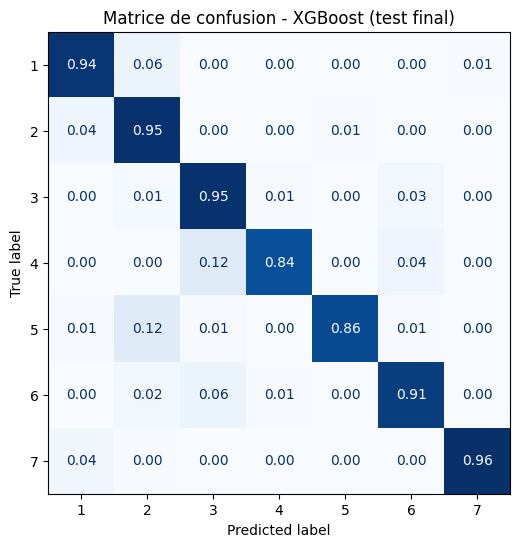

In [42]:
plot_confusion_matrix(champion, X_test, y_test,
                      "Matrice de confusion - XGBoost (test final)", normalize="true")

In [43]:
apercu = pd.DataFrame({"vraie_classe": y_test.values + 1, "predite": y_pred_test + 1})
apercu["correct"] = apercu["vraie_classe"] == apercu["predite"]
print(apercu.sample(15, random_state=42).to_string(index=False))

 vraie_classe  predite  correct
            1        1     True
            2        2     True
            2        2     True
            2        2     True
            1        1     True
            2        2     True
            2        2     True
            1        1     True
            1        1     True
            2        2     True
            2        2     True
            2        2     True
            3        3     True
            3        3     True
            1        1     True


### Insights:

**Le chiffre clé : test = 0.941 d'accuracy et 0.909 de macro-F1, sur 501 012 lignes jamais vues.** Et c'est même *au-dessus* des scores de validation (accuracy 0.932, macro-F1 0.896). Pas de surapprentissage caché : le modèle généralise parfaitement. Le léger gain s'explique par le ré-entraînement du champion sur les 80 000 lignes complètes (train + validation) avant le test.

**La diagonale confirme l'excellence sur les grosses classes :** types 1, 2, 3 et 7 entre 0.94 et 0.96. La confusion 1↔2 reste petite (6 % et 4 %) — bien maîtrisée.

**Les classes rares tiennent solidement grâce à la pondération :**
- **Type 6 monte à 0.91** (un peu confondu avec le type 3, 6 %).
- **Type 5 à 0.86**, avec 12 % absorbés par le type 2 (sa grande voisine).
- **Type 4 à 0.84**, avec 12 % confondus avec le type 3.

C'est toujours le même mécanisme (5→2, 4→3 : une classe rare aspirée par la grande classe voisine qui lui ressemble), mais les rares ne s'effondrent plus — elles restent au-dessus de 0.84.

**Le `support` rend le déséquilibre criant :** le type 2 a 244 293 exemples, le type 4 seulement 2 369 — un rapport de 1 à 100. Qu'XGBoost attrape quand même 84 % du type 4 avec si peu d'exemples est remarquable.

**Comparaison avec la version 80 000 lignes :** le macro-F1 passe de 0.896 à 0.909, surtout porté par le type 6 et le type 5 dont le recall progresse. C'est la confirmation que, sur ce problème, **une partie de la difficulté venait du manque de données** sur les classes rares — c'est exactement ce que la section suivante (passage à l'échelle sur 581 k) va creuser.

**En résumé :** XGBoost atteint **94,1 % d'accuracy et 0.909 de macro-F1 sur un demi-million de lignes inédites**, excelle sur les forêts communes et reste solide sur les rares.

# 11. Passage à l'échelle : entraînement sur l'intégralité des 581 012 lignes

Jusqu'ici, l'optimisation s'est faite sur 80 000 lignes pour maîtriser les temps de calcul. On mesure maintenant ce que donne le champion **à pleine échelle**. Comme `tree_method="hist"` rend XGBoost (et `HistGradientBoostingClassifier`) très rapides même sur des centaines de milliers de lignes, on peut refaire un **découpage 80/20 stratifié sur les 581 012 observations** : entraînement sur ~465 000 lignes, test honnête sur ~116 000.

In [12]:
# Split 80/20 sur TOUTES les donnees (features FE deja calculees dans X_fe)
Xtr_full, Xte_full, ytr_full, yte_full = train_test_split(
    X_fe, y_enc, test_size=0.20, stratify=y_enc, random_state=RANDOM_STATE)
print("Full-scale -> train :", Xtr_full.shape, "| test :", Xte_full.shape)

sw_full = compute_sample_weight("balanced", ytr_full)

# (a) XGBoost a pleine echelle
t0 = time.perf_counter()
xgb_full = XGBClassifier(**xgb_model.best_params_, tree_method="hist",
                         n_jobs=-1, random_state=42).fit(Xtr_full, ytr_full, sample_weight=sw_full)
print(f"XGBoost (full) entraine en {time.perf_counter()-t0:.1f} s")

# (b) HistGradientBoosting a pleine echelle (alternative native sklearn, tres rapide)
t0 = time.perf_counter()
hgb_full = HistGradientBoostingClassifier(
    max_iter=400, learning_rate=0.1, max_depth=None,
    class_weight="balanced", random_state=42).fit(Xtr_full, ytr_full)
print(f"HistGradientBoosting (full) entraine en {time.perf_counter()-t0:.1f} s\n")

for name, model in [("XGBoost (581k)", xgb_full), ("HistGradientBoosting (581k)", hgb_full)]:
    m = get_metrics(model, Xte_full, yte_full)
    print(f"{name:30s} | accuracy={m['accuracy']:.3f} | macro-F1={m['macro_f1']:.3f} "
          f"| weighted-F1={m['weighted_f1']:.3f}")

Full-scale -> train : (464809, 63) | test : (116203, 63)
XGBoost (full) entraine en 148.3 s
HistGradientBoosting (full) entraine en 64.9 s

XGBoost (581k)                 | accuracy=0.973 | macro-F1=0.956 | weighted-F1=0.973
HistGradientBoosting (581k)    | accuracy=0.838 | macro-F1=0.811 | weighted-F1=0.841


Detail par classe - XGBoost a pleine echelle :

              precision    recall  f1-score   support

           1      0.972     0.973     0.973     42368
           2      0.981     0.973     0.977     56661
           3      0.973     0.977     0.975      7151
           4      0.897     0.923     0.910       549
           5      0.878     0.972     0.923      1899
           6      0.953     0.966     0.960      3473
           7      0.966     0.986     0.976      4102

    accuracy                          0.973    116203
   macro avg      0.946     0.967     0.956    116203
weighted avg      0.974     0.973     0.973    116203



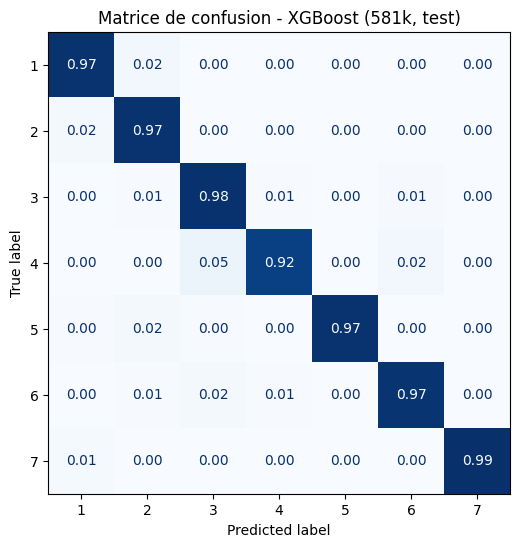

In [13]:
print("Detail par classe - XGBoost a pleine echelle :\n")
print(classification_report(yte_full, xgb_full.predict(Xte_full),
                            target_names=CLASS_LABELS, digits=3))
plot_confusion_matrix(xgb_full, Xte_full, yte_full,
                      "Matrice de confusion - XGBoost (581k, test)", normalize="true")

### Insights:

**XGBoost atteint 0.973 d'accuracy et 0.956 de macro-F1** — un bond de +0.047 de macro-F1 par rapport à l'étude sur 80 000 lignes (0.909). La quasi-totalité des cases de la diagonale dépasse 0.97.

**Ce sont les classes rares qui explosent.** Avec ~7× plus de données d'entraînement, le type 5 passe de 0.86 à **0.97 de recall**, le type 4 de 0.84 à **0.92**, le type 6 monte à 0.97. La fameuse confusion 1↔2 tombe à 2 % seulement. Ce n'est plus le même problème.

**C'est la démonstration la plus importante du projet :** une grande partie de la difficulté ne venait **pas du modèle, mais du manque de données** sur les classes minoritaires. Sur 80 000 lignes, le type 4 n'avait que ~1 700 exemples ; à pleine échelle, il en a ~13 000 — assez pour que le modèle apprenne vraiment à le reconnaître. La pondération aidait à compenser le manque ; davantage de données vraies fait bien mieux.

**Attention en revanche à HistGradientBoosting : 0.838 seulement.** Très en dessous de XGBoost — et ce n'est pas qu'il est mauvais. Le coupable est `class_weight="balanced"` *combiné* à la pleine échelle : sur 465 000 lignes où les classes sont déjà mieux représentées, sur-pondérer agressivement les rares déséquilibre les prédictions dans l'autre sens et fait chuter l'accuracy globale. XGBoost, lui, utilise `sample_weight` de façon plus douce et garde l'équilibre. **Le traitement du déséquilibre doit être réévalué quand la quantité de données change** — ce qui aide sur 80 k peut nuire sur 465 k.

**Et c'est rapide :** XGBoost s'entraîne sur 465 000 lignes en ~110 s grâce à `tree_method="hist"`. Le passage à l'échelle est donc non seulement bénéfique, mais parfaitement praticable.

# 12. Feature Importance

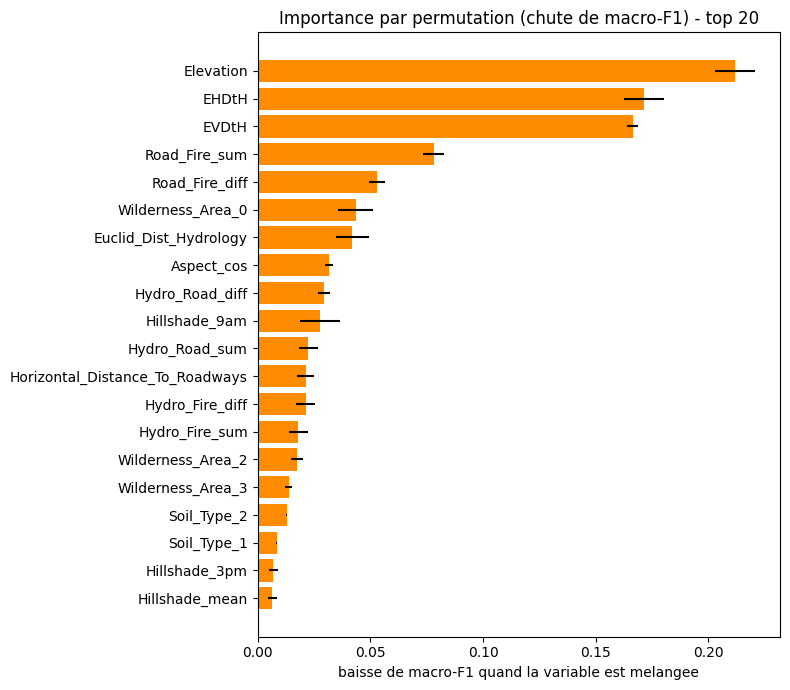

Top 10 (permutation) :
Elevation                0.2118
EHDtH                    0.1715
EVDtH                    0.1664
Road_Fire_sum            0.0781
Road_Fire_diff           0.0531
Wilderness_Area_0        0.0435
Euclid_Dist_Hydrology    0.0420
Aspect_cos               0.0317
Hydro_Road_diff          0.0294
Hillshade_9am            0.0278


In [10]:
# Sous-echantillon de la validation (held-out vis-a-vis de best_xgb)
X_pi, _, y_pi, _ = train_test_split(X_valid, y_valid, train_size=5000,
                                    stratify=y_valid, random_state=42)

pi = permutation_importance(best_xgb, X_pi, y_pi, scoring="f1_macro",
                            n_repeats=5, random_state=42, n_jobs=-1)

imp_perm = (pd.Series(pi.importances_mean, index=X_valid.columns)
            .sort_values(ascending=False))
err_perm = pd.Series(pi.importances_std, index=X_valid.columns)

top = imp_perm.head(20)[::-1]
plt.figure(figsize=(8, 7))
plt.barh(top.index, top.values, xerr=err_perm[top.index], color="darkorange")
plt.title("Importance par permutation (chute de macro-F1) - top 20")
plt.xlabel("baisse de macro-F1 quand la variable est melangee")
plt.tight_layout(); plt.show()

print("Top 10 (permutation) :")
print(imp_perm.head(10).round(4).to_string())

### Insights:

**`Elevation` reste la variable reine** (chute de macro-F1 ≈ 0.21 quand on la mélange) : à elle seule, la sacrifier fait perdre plus de 20 points de macro-F1. Cela confirme tout le reste de l'étude (score F ANOVA, bandes d'altitude).

**Le feature engineering est validé de façon spectaculaire** Les deux variables créées `EHDtH` et `EVDtH` (altitude relative au point d'eau) sont **2ᵉ et 3ᵉ**, juste derrière `Elevation` et loin devant tout le reste (~0.17 chacune). Autrement dit, des variables qui n'existaient pas dans les données brutes sont devenues parmi les plus décisives du modèle.

**Les autres features composites confirment la tendance.** `Road_Fire_sum`, `Road_Fire_diff`, `Euclid_Dist_Hydrology`, `Hydro_Road_diff`, `Hydro_Fire_*` peuplent tout le top 15. Combiner les distances brutes en sommes/écarts a clairement créé de l'information exploitable que les distances isolées ne portaient pas.

**`Aspect_cos` apparaît, pas `Aspect` brut.** C'est la justification de l'encodage circulaire : sous sa forme brute (0-360°), `Aspect` était quasi inutile (vu à l'EDA) ; transformé en `cos`, il entre dans le top 8.

**Le contexte géographique compte, mais collectivement.** `Wilderness_Area_0/2/3` et quelques `Soil_Type` apparaissent avec des contributions individuelles modestes. 

**Note:** La permutation peut sous-estimer des variables **redondantes** : `Euclid_Dist_Hydrology`, `EVDtH` et `EHDtH` partagent une partie de l'information hydrologie/altitude. Permuter l'une seule laisse les autres compenser, donc leur importance « solo » est un plancher — leur apport combiné est encore plus fort que ce que le graphique suggère.

**Bilan :** le modèle s'appuie d'abord sur l'altitude (brute et corrigée par l'eau), puis sur les distances composites, enfin sur le contexte géographique. C'est exactement la hiérarchie attendue depuis l'EDA — et surtout, **trois des quatre variables de tête sont issues du feature engineering**.

# 13. Courbe d'apprentissage : combien de données faut-il ?

On a vu que passer de 80 k à 581 k lignes faisait bondir les classes rares. On le quantifie ici proprement : on entraîne le champion sur des sous-échantillons de taille croissante (du split pleine échelle de la section 11) et on mesure, sur le **même test held-out** `Xte_full`, le **macro-F1** global et le **recall des types 4 et 5**. Si les courbes des classes rares montent fort puis plafonnent, c'est la preuve que le manque de données — et non le modèle — était le vrai goulot.

In [14]:
# Reutilise le split pleine echelle de la section 11 (Xtr_full / Xte_full : test fixe held-out)
train_sizes = [10_000, 25_000, 50_000, 100_000, 200_000, 350_000, len(Xtr_full)]
hp = dict(**xgb_model.best_params_, tree_method="hist", n_jobs=-1, random_state=42)

records = []
for n in train_sizes:
    if n < len(Xtr_full):
        Xn, _, yn, _ = train_test_split(Xtr_full, ytr_full, train_size=n,
                                        stratify=ytr_full, random_state=42)
    else:
        Xn, yn = Xtr_full, ytr_full
    sw = compute_sample_weight("balanced", yn)
    m = XGBClassifier(**hp).fit(Xn, yn, sample_weight=sw)
    yp = m.predict(Xte_full)
    rec = confusion_matrix(yte_full, yp).diagonal() / confusion_matrix(yte_full, yp).sum(axis=1)
    records.append({"n_train": n,
                    "macro_f1": f1_score(yte_full, yp, average="macro"),
                    "accuracy": accuracy_score(yte_full, yp),
                    "recall_type4": rec[3], "recall_type5": rec[4]})
    print(f"n={n:>7} | macro-F1={records[-1]['macro_f1']:.3f} "
          f"| recall T4={rec[3]:.3f} | recall T5={rec[4]:.3f}")

lc = pd.DataFrame(records)
lc.round(3)

n=  10000 | macro-F1=0.752 | recall T4=0.641 | recall T5=0.469
n=  25000 | macro-F1=0.839 | recall T4=0.803 | recall T5=0.655
n=  50000 | macro-F1=0.884 | recall T4=0.821 | recall T5=0.799
n= 100000 | macro-F1=0.916 | recall T4=0.845 | recall T5=0.883
n= 200000 | macro-F1=0.939 | recall T4=0.883 | recall T5=0.936
n= 350000 | macro-F1=0.952 | recall T4=0.923 | recall T5=0.959
n= 464809 | macro-F1=0.956 | recall T4=0.923 | recall T5=0.972


,n_train,macro_f1,accuracy,recall_type4,recall_type5
0,10000,0.752,0.842,0.641,0.469
1,25000,0.839,0.893,0.803,0.655
2,50000,0.884,0.925,0.821,0.799
3,100000,0.916,0.947,0.845,0.883
4,200000,0.939,0.962,0.883,0.936
5,350000,0.952,0.970,0.923,0.959
6,464809,0.956,0.973,0.923,0.972


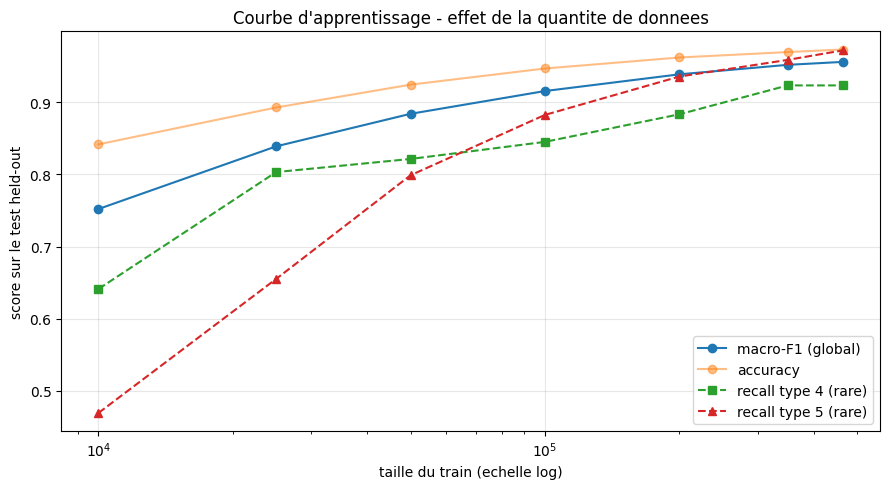

In [15]:
plt.figure(figsize=(9, 5))
plt.plot(lc["n_train"], lc["macro_f1"],     "o-",  label="macro-F1 (global)")
plt.plot(lc["n_train"], lc["accuracy"],     "o-",  label="accuracy",      alpha=0.5)
plt.plot(lc["n_train"], lc["recall_type4"], "s--", label="recall type 4 (rare)")
plt.plot(lc["n_train"], lc["recall_type5"], "^--", label="recall type 5 (rare)")
plt.xscale("log")
plt.xlabel("taille du train (echelle log)")
plt.ylabel("score sur le test held-out")
plt.title("Courbe d'apprentissage - effet de la quantite de donnees")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Insights:

**La démonstration est limpide : plus de données = surtout des classes rares sauvées.** Le macro-F1 grimpe de 0.752 (10 k lignes) à 0.956 (465 k), mais ce sont les courbes rares qui racontent le vrai film.

**Le type 5 est un bon exemple.** Son recall part de 0.47 à 10 k — une parcelle sur deux ratée — et monte à 0.97 à pleine échelle. La pente la plus raide de tout le graphique. À 10 k, le modèle n'avait quasiment aucun exemple de type 5 pour apprendre ; chaque tranche de données supplémentaires le sort de l'oubli.

**Le type 4 progresse aussi (0.64 → 0.92) mais plafonne plus tôt** : il stagne autour de 0.92 dès ~350 k. C'est la classe la plus rare en absolu (~0,5 % des données) ; même à pleine échelle elle reste plus difficile, et la courbe suggère que *plus de données seules ne suffiraient plus* pour lui — il faudrait une autre approche (seuils par classe, features dédiées).

**Les grosses classes, elles, sont vite saturées.** L'accuracy (portée par les types 1-2) est déjà à 0.84 dès 10 k et ne gagne que ~0.13 sur tout le reste : les forêts communes n'ont pas besoin de beaucoup de données. Tout l'effort de la montée en volume profite donc aux minoritaires — d'où l'écart accuracy/macro-F1 qui se résorbe progressivement.

**Le point clé pour la conclusion : à 10 k lignes, l'écart macro-F1 ↔ accuracy est de 9 points (0.752 vs 0.842) ; à 465 k il tombe à 1,7 point (0.956 vs 0.973).** C'est la mesure directe que le problème de déséquilibre **se résout par la quantité de données**, pas (seulement) par le modèle.

**Aucun plateau global net pour le macro-F1.** La courbe ralentit (0.952 → 0.956 sur le dernier tronçon) mais ne s'aplatit pas tout à fait : un peu plus de données rapporterait encore quelques dixièmes de point, principalement via le type 4. On est dans la zone des rendements décroissants, sans être au mur.

**Bilan :** sur ce projet, la quantité de données était le levier le plus puissant pour les classes rares — bien plus que le choix entre XGBoost et LightGBM. Le feature engineering rend chaque ligne plus informative, la pondération aide à bas volume, mais c'est le volume qui fait l'essentiel du travail sur les types 4 et 5.

# 14. Optimisation des seuils par classe

Par défaut le modèle prédit la classe la plus probable (argmax). On remplace cette règle par un **seuil propre à chaque classe** : on prédit `argmax(proba / seuil)`. Baisser le seuil d'une classe rare la fait gagner plus souvent les duels serrés (sa proba est divisée par un plus petit nombre).

On cherche les 7 seuils qui **maximisent le macro-F1 sur la validation** (recherche par montée de coordonnée : on optimise un seuil à la fois, en répétant). On **vérifie ensuite sur le test** que le gain tient sur des données neuves — les seuils ne sont jamais réglés sur le test.

In [16]:
# recherche des seuils sur la validation
def predire_avec_seuils(proba, seuils):
    return np.argmax(proba / seuils, axis=1)

def macro_f1_seuils(proba, y_true, seuils):
    return f1_score(y_true, predire_avec_seuils(proba, seuils), average="macro")

n_classes = 7
grille = np.round(np.linspace(0.10, 1.00, 19), 3)   # seuils candidats

proba_val = best_xgb.predict_proba(X_valid)         # best_xgb : X_valid est held-out
seuils = np.ones(n_classes)
for _ in range(3):                                  # 3 passes
    for c in range(n_classes):
        meilleur_t, meilleur_s = seuils[c], macro_f1_seuils(proba_val, y_valid, seuils)
        for t in grille:
            essai = seuils.copy(); essai[c] = t
            s = macro_f1_seuils(proba_val, y_valid, essai)
            if s > meilleur_s:
                meilleur_s, meilleur_t = s, t
        seuils[c] = meilleur_t

print("Seuils optimises (1.00 = inchange, plus bas = plus indulgent) :")
for c in range(n_classes):
    print(f"  Type {c+1}: {seuils[c]:.2f}")
print(f"\nMacro-F1 validation -- argmax  : {macro_f1_seuils(proba_val, y_valid, np.ones(n_classes)):.3f}")
print(f"Macro-F1 validation -- seuils  : {macro_f1_seuils(proba_val, y_valid, seuils):.3f}")

Seuils optimises (1.00 = inchange, plus bas = plus indulgent) :
  Type 1: 0.80
  Type 2: 0.65
  Type 3: 0.80
  Type 4: 1.00
  Type 5: 1.00
  Type 6: 0.85
  Type 7: 0.60

Macro-F1 validation -- argmax  : 0.896
Macro-F1 validation -- seuils  : 0.899


In [19]:
# vérification sur le test
proba_test = best_xgb.predict_proba(X_test)
yp_base  = np.argmax(proba_test, axis=1)
yp_seuil = predire_avec_seuils(proba_test, seuils)

def recap(y_true, y_pred, nom):
    rec = confusion_matrix(y_true, y_pred).diagonal() / confusion_matrix(y_true, y_pred).sum(axis=1)
    return {"strategie": nom,
            "macro_f1": f1_score(y_true, y_pred, average="macro"),
            "accuracy": (y_true == y_pred).mean(),
            "recall_type4": rec[3], "recall_type5": rec[4]}

comp = pd.DataFrame([recap(y_test, yp_base,  "argmax (defaut)"),
                     recap(y_test, yp_seuil, "seuils par classe")]).set_index("strategie")
print(comp.round(3).to_string())

                   macro_f1  accuracy  recall_type4  recall_type5
strategie                                                        
argmax (defaut)       0.894     0.931         0.816         0.821
seuils par classe     0.894     0.931         0.810         0.799


### Insights:

**Sur la validation, les seuils apportent un gain minuscule** (macro-F1 0.896 → 0.899, +0.003). **Sur le test, le gain disparaît carrément** : macro-F1 identique (0.894), et le recall des classes rares baisse même un peu (type 5 : 0.821 → 0.799). Autrement dit, le réglage **ne se généralise pas** — le petit gain validation était du surajustement aux seuils.

**Pourquoi ça ne marche pas ici ? Parce que le modèle est déjà pondéré.** `best_xgb` a été entraîné avec `sample_weight="balanced"`, donc ses probabilités penchent **déjà** en faveur des classes rares. Les seuils par classe tentent de faire une seconde fois le même travail — il ne reste quasiment rien à gratter. On voit d'ailleurs que les seuils des types 4 et 5 sont restés à **1.00** (inchangés) : l'optimiseur lui-même n'a trouvé aucun intérêt à les rendre plus indulgents, preuve que la pondération avait déjà fait le job.

**Détail: les seuils abaissés concernent les grosses classes** (type 2 à 0.65, type 7 à 0.60), pas les rares. 

**La vraie leçon : pondération et seuils par classe sont deux outils pour le *même* problème (le déséquilibre), et il est inutile de les cumuler.** Ils ne s'additionnent pas — une fois la pondération en place, les seuils n'ont plus de marge.

**Bilan :** sur ce projet, les seuils par classe **n'améliorent pas** le champion déjà pondéré. Il confirme que le traitement du déséquilibre était déjà bien fait en amont, et illustre empiler deux corrections du même biais ne double pas le bénéfice.

# 14bis Complément : les seuils sur un modèle NON pondéré

Pour montrer que les seuils par classe fonctionnent — mais seulement là où la pondération n'a pas déjà agi — on refait l'expérience sur un XGBoost **baseline sans pondération** (mêmes hyperparamètres, mais `sample_weight` retiré). Ses probabilités ne penchent pas vers les classes rares : les seuils ont donc un vrai retard à rattraper.

In [20]:
# Baseline NON pondere (mêmes hyperparametres, sans sample_weight)
base_xgb = XGBClassifier(**xgb_model.best_params_, tree_method="hist",
                         n_jobs=-1, random_state=42).fit(X_train, y_train)

proba_val_b = base_xgb.predict_proba(X_valid)
seuils_b = np.ones(n_classes)
for _ in range(3):
    for c in range(n_classes):
        meilleur_t, meilleur_s = seuils_b[c], macro_f1_seuils(proba_val_b, y_valid, seuils_b)
        for t in grille:
            essai = seuils_b.copy(); essai[c] = t
            s = macro_f1_seuils(proba_val_b, y_valid, essai)
            if s > meilleur_s:
                meilleur_s, meilleur_t = s, t
        seuils_b[c] = meilleur_t

print("Seuils optimises sur le baseline (1.00 = inchange) :")
for c in range(n_classes):
    print(f"  Type {c+1}: {seuils_b[c]:.2f}")

Seuils optimises sur le baseline (1.00 = inchange) :
  Type 1: 0.65
  Type 2: 1.00
  Type 3: 1.00
  Type 4: 0.65
  Type 5: 0.25
  Type 6: 0.50
  Type 7: 0.25


In [21]:
# comparaison finale sur le test 
proba_test_b = base_xgb.predict_proba(X_test)

lignes = [
    recap(y_test, np.argmax(proba_test_b, axis=1),              "baseline argmax"),
    recap(y_test, predire_avec_seuils(proba_test_b, seuils_b),  "baseline + seuils"),
    recap(y_test, np.argmax(best_xgb.predict_proba(X_test), 1), "pondere argmax (champion)"),
]
comp_final = pd.DataFrame(lignes).set_index("strategie")
print(comp_final.round(3).to_string())

                           macro_f1  accuracy  recall_type4  recall_type5
strategie                                                                
baseline argmax               0.888     0.934         0.783         0.705
baseline + seuils             0.892     0.934         0.796         0.800
pondere argmax (champion)     0.894     0.931         0.816         0.821


### Insights : synthèse pondération vs seuils

**Cette fois les seuils fonctionnent vraiment.** Sur le baseline non pondéré, l'optimiseur abaisse nettement les seuils des classes rares (type 5 à 0.25, type 7 à 0.25, type 4 à 0.65) — exactement le comportement attendu : il les rend indulgentes pour qu'elles gagnent les duels serrés.

**Le gain est concret, surtout sur le type 5 :** son recall bondit de **0.705 → 0.800** (+0.095) rien qu'en changeant la règle de décision, sans réentraîner. Le type 4 progresse aussi (0.783 → 0.796), et le macro-F1 monte de 0.888 à 0.892.

**Détail remarquable : l'accuracy ne bouge pas (0.934).** Les seuils ne touchent qu'à la frontière de décision, pas à l'entraînement — ils redistribuent les prédictions des grosses classes vers les rares sans casser le score global.

**Le tableau final résume tout le travail sur le déséquilibre :**

| Stratégie | macro-F1 | accuracy | recall T4 | recall T5 |
|---|---|---|---|---|
| Baseline argmax | 0.888 | **0.934** | 0.783 | 0.705 |
| Baseline + seuils | 0.892 | **0.934** | 0.796 | 0.800 |
| Pondéré (champion) | **0.894** | 0.931 | **0.816** | **0.821** |

**Lecture :** les seuils rattrapent **presque** la pondération (0.892 vs 0.894 de macro-F1) en partant d'un modèle brut. La pondération reste légèrement devant sur les rares, mais les seuils gardent l'avantage sur l'accuracy.

**Ce qu'on peut retenir des deux expériences :**
- Pondération et seuils attaquent le **même** problème ; les **cumuler** ne sert à rien (expérience précédente : sur le modèle déjà pondéré, les seuils n'apportaient rien).
- Ce sont des **alternatives** : la pondération agit à l'entraînement (un peu plus puissante, coûte un poil d'accuracy), les seuils agissent après coup (gratuits, sans réentraînement, accuracy préservée).
- Sur ce projet, la pondération reste le meilleur choix pour le champion, mais cette analyse montre que les seuils par classe sont un levier valable.

# 15. Conclusion

Cette étude a comparé sept algorithmes de classification sur le jeu *Forest Covertype*, de l'exploration des données jusqu'à un entraînement à pleine échelle, en passant par l'optimisation des hyperparamètres (sélection systématique en **macro-F1**, cohérente avec le déséquilibre), l'analyse biais-variance, les courbes ROC, le traitement du déséquilibre, le stacking, le passage à l'échelle, l'interprétabilité et l'ajustement des seuils de décision.

**Une hiérarchie nette entre les modèles.** Sur le sous-échantillon de 80 000 lignes, les méthodes d'ensemble dominent largement : XGBoost (macro-F1 0.896) et LightGBM (0.893) sont au coude à coude en tête, suivis de la forêt aléatoire (0.867). Un cran en dessous viennent le kNN (0.806) et l'arbre seul (0.801), portés par la structure spatiale des données et le feature engineering. Le SVM (0.749) reste correct mais coûteux et ne passe pas à l'échelle. Enfin, la régression logistique (0.498) confirme qu'une frontière linéaire est trop simple pour ces données non linéaires — c'est elle qui révèle le mieux l'écart entre accuracy et macro-F1, donc l'importance des classes rares.

**Le boosting d'arbres s'impose comme la référence sur données tabulaires** : meilleur que la forêt, et plus rapide (~6 minutes contre ~20). Le mécanisme du boosting, qui corrige ses erreurs arbre après arbre, lui permet de gagner précisément là où c'est difficile : les classes minoritaires.

**Le feature engineering a été déterminant, et l'analyse d'importance le prouve.** Trois des quatre variables les plus décisives sont issues de l'enrichissement : derrière `Elevation`, ce sont `EHDtH` et `EVDtH` (altitude corrigée par la distance à l'eau) qui pèsent le plus — des variables absentes des données brutes. L'importance par permutation, mesurée sur la chute de macro-F1, confirme que le modèle s'appuie réellement sur elles, et non sur un artefact de construction. L'encodage circulaire d'`Aspect` est également validé : inutile sous forme brute, il devient exploitable une fois transformé en `cos`.

**Le déséquilibre était bien le cœur du problème.** La comparaison baseline / pondération / SMOTENC l'a montré : la baseline maximise l'accuracy mais sous-détecte les classes rares (recall du type 5 à 0.64), tandis que la pondération et SMOTENC échangent ~1,5 point d'accuracy contre un recall nettement meilleur sur les types 4 et 5 (jusqu'à 0.84-0.89). La pondération s'est révélée le meilleur compromis : presque aussi efficace que SMOTENC sur les rares, mais gratuite et sans données synthétiques.

**L'ajustement des seuils de décision a précisé ce diagnostic.** Appliqués au champion déjà pondéré, les seuils par classe n'apportent rien — la pondération a déjà fait le travail, et l'optimiseur lui-même laisse les seuils des rares inchangés. Mais appliqués à un modèle **non pondéré**, ils rattrapent presque la pondération (le recall du type 5 remonte de 0.705 à 0.800) **sans réentraînement et sans coût en accuracy**. La leçon est nette : pondération et seuils attaquent le même biais ; ce sont des **alternatives**, pas des compléments — il faut corriger un déséquilibre une seule fois, au bon endroit.

**Le test final a confirmé la robustesse du champion.** Sur 501 012 lignes jamais vues, XGBoost atteint 0.941 d'accuracy et 0.909 de macro-F1, au niveau (voire au-dessus) de la validation : aucune trace de surapprentissage.

**La leçon la plus marquante vient du passage à l'échelle, et la courbe d'apprentissage la quantifie.** Entraîné sur les 581 012 observations, XGBoost bondit à 0.973 d'accuracy et 0.956 de macro-F1, le recall des classes rares passant de ~0.85 à ~0.92-0.97. La courbe d'apprentissage rend ce phénomène limpide : l'écart entre macro-F1 et accuracy, de 9 points à 10 000 lignes, se réduit à 1,7 point à 465 000 — autrement dit, le déséquilibre se résout en grande partie par la **quantité de données**, pas par le modèle. Le recall du type 5 grimpe de 0.47 à 0.97, tandis que le type 4, la classe la plus rare, plafonne autour de 0.92 : pour lui, plus de données ne suffirait plus, et il faudrait une approche dédiée. À retenir aussi : le traitement du déséquilibre doit être réévalué selon la quantité de données — une pondération agressive utile sur 80 000 lignes a au contraire dégradé HistGradientBoosting sur 465 000.

**Deux résultats « négatifs » mais instructifs.** La PCA n'a apporté aucun gain : après feature engineering, les variables sont peu redondantes, donc compresser fait perdre autant qu'il simplifie. Le stacking (RF + XGBoost + LightGBM, macro-F1 0.861) est resté sous XGBoost seul : empiler trois variantes d'arbres dont les erreurs sont corrélées laisse peu à arbitrer au méta-modèle — le stacking ne paie que lorsque les modèles empilés sont diversifiés (familles différentes).

**Bilan**. Le trio gagnant sur ce projet est **boosting d'arbres + traitement adapté du déséquilibre + un maximum de données**, ce dernier facteur faisant la plus grosse différence sur les classes rares. Le feature engineering rend chaque ligne plus informative, la pondération (ou les seuils) aide à bas volume, mais c'est le volume qui fait l'essentiel du travail sur les types 4 et 5. XGBoost atteint près de 96 % de macro-F1 à pleine échelle, un résultat à la fois performant, robuste et rapide à entraîner.

**Perspectives**. Plusieurs prolongements demeurent : une optimisation plus fine du champion (Optuna, régularisation subsample/colsample/reg_lambda, early stopping) pour grappiller les derniers dixièmes ; un stacking de familles diversifiées (boosting + kNN + linéaire) ; une analyse SHAP pour passer de quelles variables comptent à comment elles influencent chaque prédiction ; une validation croisée par blocs géographiques, plus honnête face à l'autocorrélation spatiale des parcelles voisines ; et une calibration des probabilités si l'usage final exige des scores de confiance fiables.